In [75]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import InputLayer,Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.layers import Layer
from keras.layers import Reshape
from keras.layers import Lambda
from keras import initializers
import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

import pandas as pd
import glob
from sklearn.preprocessing import StandardScaler
from scipy.signal import spectrogram
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## Preprocessing

In [58]:
'''def preprocessing(path):
    img = Image.open(path)
    img_resized = img.resize((224,224))
    return np.array(img_resized)/255'''

'def preprocessing(path):\n    img = Image.open(path)\n    img_resized = img.resize((224,224))\n    return np.array(img_resized)/255'

In [59]:
'''data_path = '../data/spectrograms/'
class0 = 'class_0'
class1 = 'class_1'
non_seizure = []
seizure = []
n_seizure_names = [f for f in os.listdir(os.path.join(data_path,class0))]
seizure_names = [f for f in os.listdir(os.path.join(data_path,class1))]

for path in n_seizure_names:
    non_seizure.append(preprocessing(os.path.join(data_path,class0,path)))
for path in seizure_names:
    seizure.append(preprocessing(os.path.join(data_path,class1,path)))

non_seizure_labels = [0]*len(non_seizure)
seizure_labels = [1]*len(seizure)
data = non_seizure+seizure
data_labels = non_seizure_labels+seizure_labels

X, y = shuffle(np.array(data), np.eye(2)[data_labels], random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=1/3, random_state=42)'''

"data_path = '../data/spectrograms/'\nclass0 = 'class_0'\nclass1 = 'class_1'\nnon_seizure = []\nseizure = []\nn_seizure_names = [f for f in os.listdir(os.path.join(data_path,class0))]\nseizure_names = [f for f in os.listdir(os.path.join(data_path,class1))]\n\nfor path in n_seizure_names:\n    non_seizure.append(preprocessing(os.path.join(data_path,class0,path)))\nfor path in seizure_names:\n    seizure.append(preprocessing(os.path.join(data_path,class1,path)))\n\nnon_seizure_labels = [0]*len(non_seizure)\nseizure_labels = [1]*len(seizure)\ndata = non_seizure+seizure\ndata_labels = non_seizure_labels+seizure_labels\n\nX, y = shuffle(np.array(data), np.eye(2)[data_labels], random_state=42)\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)\nX_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=1/3, random_state=42)"

In [60]:
# This new cell contains all logic from Cell 4 of your SlidingWindow notebook.
# It loads CSVs, creates windowed spectrograms, splits, and normalizes.

ROOT_DATA_FOLDER = '../data/Wave Data'
NORMAL_FOLDERS = ['A', 'B', 'C', 'D']
SEIZURE_FOLDER = 'E'
FILE_EXTENSION = '*.csv'

SAMPLING_RATE_HZ = 173.33
WINDOW_DURATION_SEC = 10.0
OVERLAP_SEC = 5.0
WINDOW_SIZE = int(WINDOW_DURATION_SEC * SAMPLING_RATE_HZ)
STEP_SIZE = int(OVERLAP_SEC * SAMPLING_RATE_HZ)        

NPERSEG = 128
NOVERLAP = NPERSEG // 2  

VAL_SIZE = 0.15
TEST_SIZE = 0.15
# ----------------------------

def process_files_to_windowed_spectrograms(root_folder, normal_folders, seizure_folder, file_ext, window_size, step_size, fs, nperseg, noverlap):
    all_spectrograms = []
    all_labels = []
    all_folders = [] 
    output_shape = None 
    # Normal Folder Preprocessing
    for folder_name in normal_folders:
        folder_path = os.path.join(root_folder, folder_name)
        if not os.path.isdir(folder_path):
            print(f"Warning: Folder not found, skipping: {folder_path}")
            continue
            
        file_paths = glob.glob(os.path.join(folder_path, file_ext))
        print(f"Processing {len(file_paths)} files from {folder_path} (Label 0)...")
        
        if not file_paths:
            print(f"Warning: No files found at {folder_path} with extension {file_ext}")
            
        for file_path in file_paths:
            try:
                signal = pd.read_csv(file_path, header=None, usecols=[1]).values.flatten()
                
                num_windows = (len(signal) - window_size) // step_size + 1
                
                for i in range(num_windows):
                    start = i * step_size
                    end = start + window_size
                    
                    window_signal = signal[start:end]
                    
                    f, t, Sxx = spectrogram(window_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
                    
                    Sxx_log = np.log1p(Sxx + 1e-6)
                    
                    Sxx_log_reshaped = Sxx_log.reshape(Sxx_log.shape[0], Sxx_log.shape[1], 1)
                    
                    if output_shape is None:
                        output_shape = Sxx_log_reshaped.shape
                        print(f"Detected spectrogram shape (freq, time, channel): {output_shape}")
                    
                    all_spectrograms.append(Sxx_log_reshaped)
                    all_labels.append(0)
                    all_folders.append(folder_name)
                        
            except Exception as e:
                print(f"Warning: Could not process {file_path}. Error: {e}")
                continue
                
    # Seizure Folde Processing
    folder_path = os.path.join(root_folder, seizure_folder)
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Error: Seizure folder not found: {folder_path}")
        
    file_paths = glob.glob(os.path.join(folder_path, file_ext))
    print(f"Processing {len(file_paths)} files from {folder_path} (Label 1)...")
    
    if not file_paths:
        print(f"Warning: No files found at {folder_path} with extension {file_ext}")
        
    for file_path in file_paths:
        try:
            signal = pd.read_csv(file_path, header=None, usecols=[1]).values.flatten()

            num_windows = (len(signal) - window_size) // step_size + 1
            
            for i in range(num_windows):
                start = i * step_size
                end = start + window_size
                window_signal = signal[start:end]
                
                f, t, Sxx = spectrogram(window_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
                Sxx_log = np.log1p(Sxx + 1e-6)
                Sxx_log_reshaped = Sxx_log.reshape(Sxx_log.shape[0], Sxx_log.shape[1], 1)
                
                all_spectrograms.append(Sxx_log_reshaped)
                all_labels.append(1) # Label 1
                all_folders.append(seizure_folder)
                
        except Exception as e:
            print(f"Warning: Could not process {file_path}. Error: {e}")
            continue
            
    if not all_spectrograms:
        raise ValueError("Error: No data was loaded.")
        
    X = np.array(all_spectrograms)
    y = np.array(all_labels)
    folders = np.array(all_folders)
    
    return X, y, folders, output_shape

def normalize_spectrograms(X_train, X_val, X_test):
    scaler = StandardScaler()
    
    num_samples_train = X_train.shape[0]
    shape_train = X_train.shape[1:]
    X_train_2d = X_train.reshape(num_samples_train, -1)

    num_samples_val = X_val.shape[0]
    shape_val = X_val.shape[1:]
    X_val_2d = X_val.reshape(num_samples_val, -1)

    num_samples_test = X_test.shape[0]
    shape_test = X_test.shape[1:]
    X_test_2d = X_test.reshape(num_samples_test, -1)
    
    scaler.fit(X_train_2d)
    
    X_train_scaled_2d = scaler.transform(X_train_2d)
    X_val_scaled_2d = scaler.transform(X_val_2d)
    X_test_scaled_2d = scaler.transform(X_test_2d)
    
    X_train_scaled = X_train_scaled_2d.reshape(num_samples_train, *shape_train)
    X_val_scaled = X_val_scaled_2d.reshape(num_samples_val, *shape_val)
    X_test_scaled = X_test_scaled_2d.reshape(num_samples_test, *shape_test)

    print("Applied Z-score normalization (fit on train data only).")
    return X_train_scaled, X_val_scaled, X_test_scaled

X, y, folders, spectro_shape = process_files_to_windowed_spectrograms(ROOT_DATA_FOLDER,NORMAL_FOLDERS,SEIZURE_FOLDER,FILE_EXTENSION,WINDOW_SIZE,STEP_SIZE,
    SAMPLING_RATE_HZ,NPERSEG,NOVERLAP)
class_counts = pd.Series(y).value_counts(normalize=True)
    
print(f"Loaded and processed {X.shape[0]} windowed spectrograms.")
print(f"Class balance:\n{class_counts * 100}")

X_train, X_temp, y_train, y_temp, folders_train, folders_temp = train_test_split(
    X, y, folders, test_size=(VAL_SIZE + TEST_SIZE), stratify=y, random_state=42
)
X_val, X_test, y_val, y_test, folders_val, folders_test = train_test_split(
    X_temp, y_temp, folders_temp,
    test_size=(TEST_SIZE / (VAL_SIZE + TEST_SIZE)), stratify=y_temp, random_state=42
)

print(f"Segregated data into 70/15/15 split:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train, X_val, X_test = normalize_spectrograms(X_train, X_val, X_test)
    
print("\nPreprocessing complete.")
print("Variables X_train, y_train, X_val, y_val, X_test, y_test are ready.")
print(f"IMPORTANT: Your model input shape is: {spectro_shape}")

Processing 100 files from ../data/Wave Data/A (Label 0)...
Detected spectrogram shape (freq, time, channel): (65, 26, 1)
Processing 100 files from ../data/Wave Data/B (Label 0)...
Processing 100 files from ../data/Wave Data/C (Label 0)...
Processing 100 files from ../data/Wave Data/D (Label 0)...
Processing 100 files from ../data/Wave Data/E (Label 1)...
Loaded and processed 1500 windowed spectrograms.
Class balance:
0    80.0
1    20.0
Name: proportion, dtype: float64
Segregated data into 70/15/15 split:
  X_train: (1050, 65, 26, 1), y_train: (1050,)
  X_val:   (225, 65, 26, 1), y_val:   (225,)
  X_test:  (225, 65, 26, 1), y_test:  (225,)
Applied Z-score normalization (fit on train data only).

Preprocessing complete.
Variables X_train, y_train, X_val, y_val, X_test, y_test are ready.
IMPORTANT: Your model input shape is: (65, 26, 1)


In [61]:
X.shape

(1500, 65, 26, 1)

## Applying SMOTE

In [20]:
'''X_flat = X_train.reshape((X_train.shape[0], -1))
smote=SMOTE(sampling_strategy='minority') 
X_train_resampled,y_train_resampled = smote.fit_resample(X_flat,y_train)
X_train = X_train_resampled.reshape((-1, 224, 224, 4))
y_train = np.eye(2)[y_train_resampled]'''

"X_flat = X_train.reshape((X_train.shape[0], -1))\nsmote=SMOTE(sampling_strategy='minority') \nX_train_resampled,y_train_resampled = smote.fit_resample(X_flat,y_train)\nX_train = X_train_resampled.reshape((-1, 224, 224, 4))\ny_train = np.eye(2)[y_train_resampled]"

In [21]:
# This is from Cell 5 of your SlidingWindow notebook.
X_flat = X_train.reshape((X_train.shape[0], -1))
smote=SMOTE(sampling_strategy='minority') 
X_train_resampled,y_train_resampled = smote.fit_resample(X_flat,y_train)
X_train = X_train_resampled.reshape((-1, 65, 26, 1))

In [22]:
# This is from Cell 6 of your SlidingWindow notebook.
y_val = np.eye(2)[y_val]
y_test = np.eye(2)[y_test]
y_train = np.eye(2)[y_train_resampled]

In [23]:
'''print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)'''

'print("X_train shape:", X_train.shape)\nprint("y_train shape:", y_train.shape)'

## Model Functions

In [62]:
def squash(inputs):
    squared_norm = K.sum(K.square(inputs), axis=-1, keepdims=True)
    return (squared_norm / (1 + squared_norm)) / (K.sqrt(squared_norm + K.epsilon())) * inputs

class PrimaryCapsuleLayer(Layer):
    def __init__(self, num_capsules, capsule_dim, **kwargs):
        super(PrimaryCapsuleLayer, self).__init__(**kwargs)
        self.num_capsules = num_capsules
        self.capsule_dim = capsule_dim
        
    def build(self, input_shape):
        super(PrimaryCapsuleLayer, self).build(input_shape)
        
    def call(self, inputs):
        batch_size = K.shape(inputs)[0]
        reshaped = K.reshape(inputs, (batch_size, self.num_capsules, self.capsule_dim))
        return squash(reshaped)
    
    def compute_output_shape(self, input_shape):
        return (None, self.num_capsules, self.capsule_dim)

class DigitCapsuleLayer(Layer):
    def __init__(self, num_classes=2, capsule_dim=16, routings=3, **kwargs):
        super(DigitCapsuleLayer, self).__init__(**kwargs)
        self.num_classes = num_classes
        self.capsule_dim = capsule_dim
        self.routings = routings
        self.kernel_initializer = initializers.get('glorot_uniform')
    
    def build(self, input_shape):
        self.num_primary_capsules = int(input_shape[1])
        self.primary_capsule_dim = int(input_shape[2])
        
        self.W = self.add_weight(
            shape=(1, self.num_primary_capsules, self.num_classes, self.primary_capsule_dim, self.capsule_dim),
            initializer=self.kernel_initializer,
            name='weights'
        )
        self.built = True
    
    def call(self, inputs):
        batch_size = K.shape(inputs)[0]
        
        W_tiled = K.tile(self.W, [batch_size, 1, 1, 1, 1])
        
        inputs_expanded = K.expand_dims(K.expand_dims(inputs, 2), -1)
        inputs_tiled = K.tile(inputs_expanded, [1, 1, self.num_classes, 1, 1])
        
        # Matrix multiplication: (batch_size, num_primary_capsules, num_classes, capsule_dim)
        u_hat = K.sum(inputs_tiled * W_tiled, axis=3)
        
        b = tf.zeros(shape=[batch_size, self.num_primary_capsules, self.num_classes])
        
        for i in range(self.routings):
            c = K.softmax(b, axis=-1)  # (batch_size, num_primary_capsules, num_classes)
            
            c_expanded = K.expand_dims(c, -1)  # (batch_size, num_primary_capsules, num_classes, 1)
            s = K.sum(c_expanded * u_hat, axis=1)  # Sum over primary capsules
            
            # Squash to get output capsules
            v = squash(s)  # (batch_size, num_classes, capsule_dim)
            
            # Update routing coefficients (except for last iteration)
            if i < self.routings - 1:
                v_expanded = K.expand_dims(v, 1)
                agreement = K.sum(u_hat * v_expanded, axis=-1)
                b = b + agreement
        
        return v
    
    def compute_output_shape(self, input_shape):
        return (None, self.num_classes, self.capsule_dim)

def output_layer(inputs):
    return K.sqrt(K.sum(K.square(inputs), -1) + K.epsilon())

def mask(outputs):
    if type(outputs) != list:
        norm_outputs = K.sqrt(K.sum(K.square(outputs), -1) + K.epsilon())
        y = K.one_hot(indices=K.argmax(norm_outputs, 1), num_classes=2)
        y = K.expand_dims(y, -1)  # (batch_size, num_classes, 1)
        return Flatten()(y * outputs)
    else:
        y = K.expand_dims(outputs[1], -1)  # (batch_size, num_classes, 1)
        masked_output = y * outputs[0]
        return Flatten()(masked_output)

def loss_fn(y_true, y_pred):
    L = y_true * K.square(K.maximum(0., 0.9 - y_pred)) + \
        0.5 * (1 - y_true) * K.square(K.maximum(0., y_pred - 0.1))
    return K.mean(K.sum(L, 1))

In [25]:
# input_tensor = Input(shape=(224, 224, 4))

# conv1 = Conv2D(256, (9, 9), activation='relu', padding='valid')(input_tensor)
# conv2 = Conv2D(256, (9, 9), strides=2, activation='relu', padding='valid')(conv1)

# conv2_reshaped = Conv2D(256, (9, 9), strides=2, activation='relu', padding='valid')(conv2)

# primary_capsules_dim = 8
# num_primary_capsules = (48 * 48 * 256) // primary_capsules_dim

# primary_caps = PrimaryCapsuleLayer(
#     num_capsules=num_primary_capsules, 
#     capsule_dim=primary_capsules_dim
# )(Flatten()(conv2_reshaped))

# # Digit capsules
# digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=16, routings=3)(primary_caps)

# # Output layer
# outputs = Lambda(output_layer)(digit_caps)

# # Masking for decoder
# inputs_label = Input(shape=(2,))
# masked = Lambda(mask)([digit_caps, inputs_label])
# masked_for_test = Lambda(mask)(digit_caps)

# # Decoder
# decoded_inputs = Input(shape=(2 * 16,))  # 2 classes * 16 dim
# dense1 = Dense(512, activation='relu')(decoded_inputs)
# dense2 = Dense(1024, activation='relu')(dense1)
# decoded_outputs = Dense(224 * 224 * 4, activation='sigmoid')(dense2)
# decoded_outputs = Reshape((224, 224, 4))(decoded_outputs)

# decoder = Model(decoded_inputs, decoded_outputs)

# # Final models
# model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
# test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

# print("Model created successfully!")
# print(f"Model input shape: {model.input_shape}")
# print(f"Model output shape: {model.output_shape}")

In [26]:
# # Compile model
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss=[loss_fn, 'mse'],
#     loss_weights=[1., 0.0005],
#     metrics=['accuracy' , None]
# )

In [28]:
# # Callbacks
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# checkpoint = ModelCheckpoint(
#     '/Users/harshitpuralkar/Desktop/Projects/DL Project/MED_RES/weights/CapsuleNet.weights.h5',
#     monitor='val_loss',
#     save_best_only=True,
#     save_weights_only=True
# )

In [30]:
# # Train the model
# history = model.fit(
#     [X_train, y_train],  
#     [y_train, X_train],  
#     validation_data=([X_val, y_val], [y_val, X_val]),
#     epochs=30,
#     batch_size=20,
#     callbacks=[early_stopping, checkpoint]
# )

## Model Optimization

In [26]:
import gc
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Reshape, Lambda
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.backend import clear_session
from hyperopt import STATUS_OK, STATUS_FAIL
import hyperopt
from hyperopt import tpe, hp, fmin, Trials

In [35]:
'''def objective(params):
    try:
        import gc
        K.clear_session()
        gc.collect()

        input_tensor = Input(shape=(224, 224, 4))

        conv1 = Conv2D(params['conv1s'], (params['conv1k'], params['conv1k']), activation='relu', padding='same')(input_tensor)
        conv2 = Conv2D(params['conv2s'], (params['conv2k'], params['conv2k']), strides=params['conv2str'], activation='relu', padding='same')(conv1)
        conv2_reshaped = Conv2D(params['convrs'], (params['convrk'], params['convrk']), strides=2, activation='relu', padding='same')(conv2)
        conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

        conv_flatten = Flatten()(conv2_reshaped)

        primary_capsules_dim = params['capsuel_dim']
        h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
        num_primary_capsules = (h * w * c) // primary_capsules_dim

        primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
        digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=params['dig_caps'], routings=3)(primary_caps)
        outputs = Lambda(output_layer)(digit_caps)

        inputs_label = Input(shape=(2,))
        masked = Lambda(mask)([digit_caps, inputs_label])
        masked_for_test = Lambda(mask)(digit_caps)

        decoded_inputs = Input(shape=(2 * params['dig_caps'],))
        dense1 = Dense(params['dense1'], activation='relu')(decoded_inputs)
        dense2 = Dense(params['dense2'], activation='relu')(dense1)
        decoded_outputs = Dense(224 * 224 * 4, activation='sigmoid')(dense2)
        decoded_outputs = Reshape((224, 224, 4))(decoded_outputs)

        decoder = Model(decoded_inputs, decoded_outputs)

        model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
        test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

        model.compile(
            optimizer=Adam(learning_rate=params['lr']),
            loss=[loss_fn, 'mse'],
            loss_weights=[1., 0.0005],
            metrics=['accuracy', None]
        )

        early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        history = model.fit(
            [X_train, y_train],
            [y_train, X_train],
            validation_data=([X_val, y_val], [y_val, X_val]),
            epochs=30,
            batch_size=8,
            callbacks=[early_stopping],
            verbose=0
        )

        val_loss = min(history.history['val_loss'])

        # Clean-up
        del model
        gc.collect()
        K.clear_session()

        return {'loss': val_loss, 'status': STATUS_OK}

    except tf.errors.ResourceExhaustedError as e:
        print("OOM error, skipping trial.")
        return {'loss': float('inf'), 'status': STATUS_FAIL}
    except Exception as e:
        print("Other error:", e)
        return {'loss': float('inf'), 'status': STATUS_FAIL}'''

'def objective(params):\n    try:\n        import gc\n        K.clear_session()\n        gc.collect()\n\n        input_tensor = Input(shape=(224, 224, 4))\n\n        conv1 = Conv2D(params[\'conv1s\'], (params[\'conv1k\'], params[\'conv1k\']), activation=\'relu\', padding=\'same\')(input_tensor)\n        conv2 = Conv2D(params[\'conv2s\'], (params[\'conv2k\'], params[\'conv2k\']), strides=params[\'conv2str\'], activation=\'relu\', padding=\'same\')(conv1)\n        conv2_reshaped = Conv2D(params[\'convrs\'], (params[\'convrk\'], params[\'convrk\']), strides=2, activation=\'relu\', padding=\'same\')(conv2)\n        conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)\n\n        conv_flatten = Flatten()(conv2_reshaped)\n\n        primary_capsules_dim = params[\'capsuel_dim\']\n        h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])\n        num_primary_capsules = (h * w * c) // primary_capsules_dim\n\n        primary_caps = Prima

In [11]:
def objective(params):
    try:
        import gc
        K.clear_session()
        gc.collect()

        # --- FIX: Update input shape ---
        input_tensor = Input(shape=(65, 26, 1))

        conv1 = Conv2D(params['conv1s'], (params['conv1k'], params['conv1k']), activation='relu', padding='same')(input_tensor)
        conv2 = Conv2D(params['conv2s'], (params['conv2k'], params['conv2k']), strides=params['conv2str'], activation='relu', padding='same')(conv1)
        conv2_reshaped = Conv2D(params['convrs'], (params['convrk'], params['convrk']), strides=2, activation='relu', padding='same')(conv2)
        conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

        conv_flatten = Flatten()(conv2_reshaped)

        primary_capsules_dim = params['capsuel_dim']
        h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
        num_primary_capsules = (h * w * c) // primary_capsules_dim

        primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
        digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=params['dig_caps'], routings=3)(primary_caps)
        outputs = Lambda(output_layer, name='capsule_output')(digit_caps)

        inputs_label = Input(shape=(2,))
        masked = Lambda(mask)([digit_caps, inputs_label])
        masked_for_test = Lambda(mask)(digit_caps)

        decoded_inputs = Input(shape=(2 * params['dig_caps'],))
        dense1 = Dense(params['dense1'], activation='relu')(decoded_inputs)
        dense2 = Dense(params['dense2'], activation='relu')(dense1)
        
        # --- FIX: Update decoder output shape to match input ---
        decoded_outputs = Dense(65 * 26 * 1, activation='sigmoid')(dense2)
        decoded_outputs = Reshape((65, 26, 1))(decoded_outputs)

        decoder = Model(decoded_inputs, decoded_outputs)

        model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
        test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

        model.compile(
            optimizer=Adam(learning_rate=params['lr']),\
            loss=[loss_fn, 'mse'],
            loss_weights=[1., 0.0005],
            metrics=['accuracy', None]
        )

        early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

        history = model.fit(
            [X_train, y_train],
            [y_train, X_train],  # <-- Decoder target is X_train
            validation_data=([X_val, y_val], [y_val, X_val]), # <-- Decoder target is X_val
            epochs=30,
            batch_size=8,
            callbacks=[early_stopping],
            verbose=2
        )

        val_loss = min(history.history['val_loss'])

        # Clean-up
        del model
        gc.collect()
        K.clear_session()

        return {'loss': val_loss, 'status': STATUS_OK}

    except tf.errors.ResourceExhaustedError as e:
        print("OOM error, skipping trial.")
        return {'loss': float('inf'), 'status': STATUS_FAIL}
    except Exception as e:
        print("Other error:", e)
        return {'loss': float('inf'), 'status': STATUS_FAIL}

In [27]:
space = {
    'conv1s': hp.choice('conv1s', [64, 128, 256, 512]),
    'conv1k': hp.choice('conv1k', [3, 5, 7, 9, 11]),
    'conv2s': hp.choice('conv2s', [64, 128,256, 512]),
    'conv2k': hp.choice('conv2k', [3, 5, 7, 9, 11]),
    'conv2str': hp.choice('conv2str', [1, 2, 3]),
    'convrs': hp.choice('convrs', [64, 128, 256, 512]),
    'convrk': hp.choice('convrk', [3, 5, 7, 9, 11]),
    'capsuel_dim': hp.choice('capsuel_dim', [8, 16]),
    'dig_caps': hp.choice('dig_caps', [8, 16, 32]),
    'dense1': hp.choice('dense1', [256, 512, 1024]),
    'dense2': hp.choice('dense2', [512, 1024, 2048]),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3))
}

'''space = {
    'conv1s': hp.choice('conv1s', [64, 128, 256]),
    'conv1k': hp.choice('conv1k', [3, 5, 7, 9]),
    'conv2s': hp.choice('conv2s', [64, 128, 256]),
    'conv2k': hp.choice('conv2k', [3, 5, 7, 9]),
    'conv2str': hp.choice('conv2str', [1, 2]),
    'convrs': hp.choice('convrs', [64, 128, 256]),
    'convrk': hp.choice('convrk', [3, 5, 7, 9]),
    'capsuel_dim': hp.choice('capsuel_dim', [8, 16]),
    'dig_caps': hp.choice('dig_caps', [8, 16]),
    'dense1': hp.choice('dense1', [256, 512]),
    'dense2': hp.choice('dense2', [512, 1024]),
    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3))
}'''

"space = {\n    'conv1s': hp.choice('conv1s', [64, 128, 256]),\n    'conv1k': hp.choice('conv1k', [3, 5, 7, 9]),\n    'conv2s': hp.choice('conv2s', [64, 128, 256]),\n    'conv2k': hp.choice('conv2k', [3, 5, 7, 9]),\n    'conv2str': hp.choice('conv2str', [1, 2]),\n    'convrs': hp.choice('convrs', [64, 128, 256]),\n    'convrk': hp.choice('convrk', [3, 5, 7, 9]),\n    'capsuel_dim': hp.choice('capsuel_dim', [8, 16]),\n    'dig_caps': hp.choice('dig_caps', [8, 16]),\n    'dense1': hp.choice('dense1', [256, 512]),\n    'dense2': hp.choice('dense2', [512, 1024]),\n    'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3))\n}"

## Saving Optimized Values

In [42]:
'''import pickle
from hyperopt import fmin, tpe, Trials
import os

TRIALS_FILE = "hyperopt_trials.pkl"
MAX_EVALS = 5

# Load existing trials if available
if os.path.exists(TRIALS_FILE):
    print("Loading existing trials...")
    with open(TRIALS_FILE, "rb") as f:
        trials = pickle.load(f)
    current_evals = len(trials.trials)
    print(f"Resuming from {current_evals} trials")
else:
    trials = Trials()
    current_evals = 0
    print("Starting new trials")

# Run optimization
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=trials
)

# Save updated trials
with open(TRIALS_FILE, "wb") as f:
    pickle.dump(trials, f)

print("Best hyperparameters:", best)'''

import pickle
from hyperopt import fmin, tpe, Trials
import os

TRIALS_FILE = "hyperopt_trials.pkl"
MAX_EVALS = 10  # <-- NOTE: Increased from 5 to 20 for a better search

# Load existing trials if available
if os.path.exists(TRIALS_FILE):
    print("Loading existing trials...")
    with open(TRIALS_FILE, "rb") as f:
        trials = pickle.load(f)
    current_evals = len(trials.trials)
    print(f"Resuming from {current_evals} trials")
else:
    trials = Trials()
    current_evals = 0
    print("Starting new trials")

# Run optimization
# This will create the 'best' variable containing the NEWLY found parameters
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=MAX_EVALS,
    trials=trials
)

# Save updated trials
with open(TRIALS_FILE, "wb") as f:
    pickle.dump(trials, f)

print("Best hyperparameters found:", best)

Loading existing trials...
Resuming from 5 trials
Epoch 1/30                                                                      

210/210 - 33s - 156ms/step - capsule_output_accuracy: 0.7976 - capsule_output_loss: 0.1854 - functional_loss: 1.5753 - loss: 0.1862 - val_capsule_output_accuracy: 0.9867 - val_capsule_output_loss: 0.0209 - val_functional_loss: 1.0913 - val_loss: 0.0221

Epoch 2/30                                                                      

210/210 - 31s - 148ms/step - capsule_output_accuracy: 0.9881 - capsule_output_loss: 0.0106 - functional_loss: 1.5749 - loss: 0.0114 - val_capsule_output_accuracy: 0.9867 - val_capsule_output_loss: 0.0147 - val_functional_loss: 1.0906 - val_loss: 0.0157

Epoch 3/30                                                                      

210/210 - 30s - 142ms/step - capsule_output_accuracy: 0.9917 - capsule_output_loss: 0.0073 - functional_loss: 1.5743 - loss: 0.0081 - val_capsule_output_accuracy: 0.9822 - val_capsule_output_loss:

In [65]:
'''values = {
    'conv1s': [64, 128, 256, 512],
    'conv1k': [3, 5, 7, 9, 11],
    'conv2s': [64, 128,256, 512],
    'conv2k': [3, 5, 7, 9, 11],
    'conv2str': [1, 2, 3],
    'convrs': [64, 128, 256, 512],
    'convrk': [3, 5, 7, 9, 11],
    'capsuel_dim': [8, 16],
    'dig_caps': [8, 16, 32],
    'dense1': [256, 512, 1024],
    'dense2': [512, 1024, 2048],
}'''

'''values = {
    'conv1s': [64, 128, 256],
    'conv1k': [3, 5, 7, 9],
    'conv2s': [64, 128,256],
    'conv2k': [3, 5, 7, 9],
    'conv2str': [1, 2],
    'convrs': [64, 128, 256],
    'convrk': [3, 5, 7, 9],
    'capsuel_dim': [8, 16],
    'dig_caps': [8, 16],
    'dense1': [256, 512],
    'dense2': [512, 1024],
}'''
values = {
    'conv1s': [64, 128, 256, 512],
    'conv1k': [3, 5, 7, 9, 11],
    'conv2s': [64, 128, 256, 512],
    'conv2k': [3, 5, 7, 9, 11],
    'conv2str': [1, 2, 3],
    'convrs': [64, 128, 256, 512],
    'convrk': [3, 5, 7, 9, 11],
    'capsuel_dim': [8, 16],
    'dig_caps': [8, 16, 32],
    'dense1': [256, 512, 1024],
    'dense2': [512, 1024, 2048],
}

In [66]:
best = {
    'capsuel_dim': np.int64(0),
    'conv1k': np.int64(1),
    'conv1s': np.int64(2),
    'conv2k': np.int64(1),
    'conv2s': np.int64(2),
    'conv2str': np.int64(1),
    'convrk': np.int64(2),
    'convrs': np.int64(3),
    'dense1': np.int64(2),
    'dense2': np.int64(1),
    'dig_caps': np.int64(0),
    'lr': np.float64(5.371502332848463e-05)
}

In [67]:
print("Best hyperparameters:", best)

Best hyperparameters: {'capsuel_dim': np.int64(0), 'conv1k': np.int64(1), 'conv1s': np.int64(2), 'conv2k': np.int64(1), 'conv2s': np.int64(2), 'conv2str': np.int64(1), 'convrk': np.int64(2), 'convrs': np.int64(3), 'dense1': np.int64(2), 'dense2': np.int64(1), 'dig_caps': np.int64(0), 'lr': np.float64(5.371502332848463e-05)}


In [68]:
optimized_values = {
    'conv1s': values['conv1s'][best['conv1s']],
    'conv1k': values['conv1k'][best['conv1k']],
    'conv2s': values['conv2s'][best['conv2s']],
    'conv2k': values['conv2k'][best['conv2k']],
    'conv2str': values['conv2str'][best['conv2str']],
    'convrs': values['convrs'][best['convrs']],
    'convrk': values['convrk'][best['convrk']],
    'capsuel_dim': values['capsuel_dim'][best['capsuel_dim']],
    'dig_caps': values['dig_caps'][best['dig_caps']],
    'dense1': values['dense1'][best['dense1']],
    'dense2': values['dense2'][best['dense2']],
    'lr': best['lr']
}

In [78]:
import json

# Convert the data to a JSON string
json_data = json.dumps(optimized_values, indent=2) 

# Write the JSON string to a file
with open('data.json', 'w') as file:
  file.write(json_data)

print("Data written to data.json")

Data written to data.json


## Model Creation

In [81]:
'''input_tensor = Input(shape=(224, 224, 4))

conv1 = Conv2D(optimized_values['conv1s'], (optimized_values['conv1k'], optimized_values['conv1k']), activation='relu', padding='same')(input_tensor)
conv2 = Conv2D(optimized_values['conv2s'], (optimized_values['conv2k'],optimized_values['conv2k']), strides=optimized_values['conv2str'], activation='relu', padding='same')(conv1)
conv2_reshaped = Conv2D(optimized_values['convrs'], (optimized_values['convrk'], optimized_values['convrk']), strides=2, activation='relu', padding='same')(conv2)
conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

conv_flatten = Flatten()(conv2_reshaped)

primary_capsules_dim = optimized_values['capsuel_dim']
h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
num_primary_capsules = (h * w * c) // primary_capsules_dim

primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=optimized_values['dig_caps'], routings=3)(primary_caps)
outputs = Lambda(output_layer)(digit_caps)

inputs_label = Input(shape=(2,))
masked = Lambda(mask)([digit_caps, inputs_label])
masked_for_test = Lambda(mask)(digit_caps)

decoded_inputs = Input(shape=(2 * optimized_values['dig_caps'],))
dense1 = Dense(optimized_values['dense1'], activation='relu')(decoded_inputs)
dense2 = Dense(optimized_values['dense2'], activation='relu')(dense1)
decoded_outputs = Dense(128 * 128 * 4, activation='sigmoid')(dense2)
decoded_outputs = Reshape((128, 128, 4))(decoded_outputs)

decoder = Model(decoded_inputs, decoded_outputs)

model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']),
    loss=[loss_fn, 'mse'],
    loss_weights=[1., 0.0005],
    metrics=['accuracy', None]
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    '../weights/CapsuleNet.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)'''

"input_tensor = Input(shape=(224, 224, 4))\n\nconv1 = Conv2D(optimized_values['conv1s'], (optimized_values['conv1k'], optimized_values['conv1k']), activation='relu', padding='same')(input_tensor)\nconv2 = Conv2D(optimized_values['conv2s'], (optimized_values['conv2k'],optimized_values['conv2k']), strides=optimized_values['conv2str'], activation='relu', padding='same')(conv1)\nconv2_reshaped = Conv2D(optimized_values['convrs'], (optimized_values['convrk'], optimized_values['convrk']), strides=2, activation='relu', padding='same')(conv2)\nconv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)\n\nconv_flatten = Flatten()(conv2_reshaped)\n\nprimary_capsules_dim = optimized_values['capsuel_dim']\nh, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])\nnum_primary_capsules = (h * w * c) // primary_capsules_dim\n\nprimary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)\ndigit_caps

In [35]:
input_tensor = Input(shape=(65, 26, 1)) # <-- FIX

conv1 = Conv2D(optimized_values['conv1s'], (optimized_values['conv1k'], optimized_values['conv1k']), activation='relu', padding='same')(input_tensor)
conv2 = Conv2D(optimized_values['conv2s'], (optimized_values['conv2k'],optimized_values['conv2k']), strides=optimized_values['conv2str'], activation='relu', padding='same')(conv1)
conv2_reshaped = Conv2D(optimized_values['convrs'], (optimized_values['convrk'], optimized_values['convrk']), strides=2, activation='relu', padding='same')(conv2)
conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

conv_flatten = Flatten()(conv2_reshaped)

primary_capsules_dim = optimized_values['capsuel_dim']
h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
num_primary_capsules = (h * w * c) // primary_capsules_dim

primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=optimized_values['dig_caps'], routings=3)(primary_caps)
outputs = Lambda(output_layer, name='capsule_output')(digit_caps)

inputs_label = Input(shape=(2,))
masked = Lambda(mask)([digit_caps, inputs_label])
masked_for_test = Lambda(mask)(digit_caps)

decoded_inputs = Input(shape=(2 * optimized_values['dig_caps'],))
dense1 = Dense(optimized_values['dense1'], activation='relu')(decoded_inputs)
dense2 = Dense(optimized_values['dense2'], activation='relu')(dense1)

# --- FIX: Update decoder output shape ---
decoded_outputs = Dense(65 * 26 * 1, activation='sigmoid')(dense2)
decoded_outputs = Reshape((65, 26, 1))(decoded_outputs)

decoder = Model(decoded_inputs, decoded_outputs)

model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']),
    loss=[loss_fn, 'mse'],
    loss_weights=[1., 0.0005],
    metrics=['accuracy', None]
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    '../weights/CapsuleNet.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

I0000 00:00:1776938884.207334    4457 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [85]:
'''input_tensor = Input(shape=(224, 224, 4))

conv1_filters = max(1, optimized_values['conv1s'])
conv1_kernel = max(1, optimized_values['conv1k'])
conv2_filters = max(1, optimized_values['conv2s'])
conv2_kernel = max(1, optimized_values['conv2k'])
conv2_stride = max(1, optimized_values['conv2str'])
convrs_filters = max(1, optimized_values['convrs'])
convrk_kernel = max(1, optimized_values['convrk'])
dense1_units = max(1, optimized_values['dense1'])
dense2_units = max(1, optimized_values['dense2'])

conv1 = Conv2D(conv1_filters, (conv1_kernel, conv1_kernel), activation='relu', padding='same')(input_tensor)
conv2 = Conv2D(conv2_filters, (conv2_kernel, conv2_kernel), strides=conv2_stride, activation='relu', padding='same')(conv1)
conv2_reshaped = Conv2D(convrs_filters, (convrk_kernel, convrk_kernel), strides=2, activation='relu', padding='same')(conv2)
conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

conv_flatten = Flatten()(conv2_reshaped)

primary_capsules_dim = max(1, optimized_values['capsuel_dim'])
h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
num_primary_capsules = (h * w * c) // primary_capsules_dim

primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=optimized_values['dig_caps'], routings=3)(primary_caps)
outputs = Lambda(output_layer)(digit_caps)

inputs_label = Input(shape=(2,))
masked = Lambda(mask)([digit_caps, inputs_label])
masked_for_test = Lambda(mask)(digit_caps)

decoded_inputs = Input(shape=(2 * optimized_values['dig_caps'],))
dense1 = Dense(dense1_units, activation='relu')(decoded_inputs)
dense2 = Dense(dense2_units, activation='relu')(dense1)
decoded_outputs = Dense(128 * 128 * 4, activation='sigmoid')(dense2)
decoded_outputs = Reshape((128, 128, 4))(decoded_outputs)

decoder = Model(decoded_inputs, decoded_outputs)

model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']),
    loss=[loss_fn, 'mse'],
    loss_weights=[1., 0.0005],
    metrics=['accuracy', 'mse']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    '../weights/CapsuleNet.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)'''

"input_tensor = Input(shape=(224, 224, 4))\n\nconv1_filters = max(1, optimized_values['conv1s'])\nconv1_kernel = max(1, optimized_values['conv1k'])\nconv2_filters = max(1, optimized_values['conv2s'])\nconv2_kernel = max(1, optimized_values['conv2k'])\nconv2_stride = max(1, optimized_values['conv2str'])\nconvrs_filters = max(1, optimized_values['convrs'])\nconvrk_kernel = max(1, optimized_values['convrk'])\ndense1_units = max(1, optimized_values['dense1'])\ndense2_units = max(1, optimized_values['dense2'])\n\nconv1 = Conv2D(conv1_filters, (conv1_kernel, conv1_kernel), activation='relu', padding='same')(input_tensor)\nconv2 = Conv2D(conv2_filters, (conv2_kernel, conv2_kernel), strides=conv2_stride, activation='relu', padding='same')(conv1)\nconv2_reshaped = Conv2D(convrs_filters, (convrk_kernel, convrk_kernel), strides=2, activation='relu', padding='same')(conv2)\nconv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)\n\nconv_flatten = Flatten()(conv2_reshaped)\n\nprimary_capsul

In [87]:
input_tensor = Input(shape=(65, 26, 1))

conv1_filters = max(1, optimized_values['conv1s'])
conv1_kernel = max(1, optimized_values['conv1k'])
conv2_filters = max(1, optimized_values['conv2s'])
conv2_kernel = max(1, optimized_values['conv2k'])
conv2_stride = max(1, optimized_values['conv2str'])
convrs_filters = max(1, optimized_values['convrs'])
convrk_kernel = max(1, optimized_values['convrk'])
dense1_units = max(1, optimized_values['dense1'])
dense2_units = max(1, optimized_values['dense2'])

conv1 = Conv2D(conv1_filters, (conv1_kernel, conv1_kernel), activation='relu', padding='same')(input_tensor)
conv2 = Conv2D(conv2_filters, (conv2_kernel, conv2_kernel), strides=conv2_stride, activation='relu', padding='same')(conv1)
conv2_reshaped = Conv2D(convrs_filters, (convrk_kernel, convrk_kernel), strides=2, activation='relu', padding='same')(conv2)
conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

conv_flatten = Flatten()(conv2_reshaped)

primary_capsules_dim = max(1, optimized_values['capsuel_dim'])
h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
num_primary_capsules = (h * w * c) // primary_capsules_dim

primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=optimized_values['dig_caps'], routings=3)(primary_caps)
outputs = Lambda(output_layer, name='capsule_output')(digit_caps)

inputs_label = Input(shape=(2,))
masked = Lambda(mask)([digit_caps, inputs_label])
masked_for_test = Lambda(mask)(digit_caps)

decoded_inputs = Input(shape=(2 * optimized_values['dig_caps'],))
dense1 = Dense(dense1_units, activation='relu')(decoded_inputs)
dense2 = Dense(dense2_units, activation='relu')(dense1)

# --- FIX: Update decoder output shape ---
decoded_outputs = Dense(65 * 26 * 1, activation='sigmoid')(dense2) # <-- FIX: Pass the tensor 'dense2'
decoded_outputs = Reshape((65, 26, 1))(decoded_outputs)

decoder = Model(decoded_inputs, decoded_outputs)

model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']),
    loss=[loss_fn, 'mse'],
    loss_weights=[1., 0.0005],
    metrics=['accuracy', 'mse']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint = ModelCheckpoint(
    '../weights/CapsuleNet.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

In [36]:
model.summary()
print(X_train.shape, y_train.shape)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 65, 26, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 65, 26,    │      6,656 │ input_layer[0][0] │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 33, 13,    │  1,638,656 │ conv2d[0][0]      │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 17, 7,     │  6,423,040 │ conv2d_1[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 8, 3, 512) │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 12288)     │          0 │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ primary_capsule_la… │ (None, 1536, 8)   │          0 │ flatten[0][0]     │
│ (PrimaryCapsuleLay… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digit_capsule_layer │ (None, 2, 8)      │    196,608 │ primary_capsule_… │
│ (DigitCapsuleLayer) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 16)        │          0 │ digit_capsule_la… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ capsule_output      │ (None, 2)         │          0 │ digit_capsule_la… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ (None, 65, 26, 1) │  2,799,258 │ lambda[0][0]      │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,064,218 (42.21 MB)

 Trainable params: 11,064,218 (42.21 MB)

 Non-trainable params: 0 (0.00 B)

(1680, 65, 26, 1) (1680, 2)


In [91]:
'''import tensorflow as tf

# Resize input for decoder target
X_train_resized = tf.image.resize(X_train, (128, 128))
X_val_resized = tf.image.resize(X_val, (128, 128))

# Training
history = model.fit(
  [X_train, y_train],
  [y_train, X_train_resized],
  validation_data=([X_val, y_val], [y_val, X_val_resized]),
  epochs=30,
  batch_size=8,
  callbacks=[early_stopping, checkpoint],
  verbose=1
)

val_loss = min(history.history['val_loss'])'''

"import tensorflow as tf\n\n# Resize input for decoder target\nX_train_resized = tf.image.resize(X_train, (128, 128))\nX_val_resized = tf.image.resize(X_val, (128, 128))\n\n# Training\nhistory = model.fit(\n  [X_train, y_train],\n  [y_train, X_train_resized],\n  validation_data=([X_val, y_val], [y_val, X_val_resized]),\n  epochs=30,\n  batch_size=8,\n  callbacks=[early_stopping, checkpoint],\n  verbose=1\n)\n\nval_loss = min(history.history['val_loss'])"

In [93]:
import tensorflow as tf

# The decoder's output is now (65, 26, 1), so it should
# be trained to reconstruct the original X_train.
# The resize lines are no longer needed.

# Training
history = model.fit(
  [X_train, y_train],
  [y_train, X_train],  # <-- FIX: Use X_train as the decoder target
  validation_data=([X_val, y_val], [y_val, X_val]), # <-- FIX: Use X_val
  epochs=30,
  batch_size=8,
  callbacks=[early_stopping, checkpoint],
  verbose=1
)

val_loss = min(history.history['val_loss'])

Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 62s 289ms/step - capsule_output_accuracy: 0.7400 - capsule_output_loss: 0.2658 - functional_3_loss: 1.5962 - functional_3_mse: 1.5962 - loss: 0.2666 - val_capsule_output_accuracy: 0.9733 - val_capsule_output_loss: 0.0177 - val_functional_3_loss: 1.0910 - val_functional_3_mse: 1.0871 - val_loss: 0.0188
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 67s 318ms/step - capsule_output_accuracy: 0.9915 - capsule_output_loss: 0.0066 - functional_3_loss: 1.5439 - functional_3_mse: 1.5439 - loss: 0.0074 - val_capsule_output_accuracy: 0.9733 - val_capsule_output_loss: 0.0151 - val_functional_3_loss: 1.0898 - val_functional_3_mse: 1.0859 - val_loss: 0.0161
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 70s 333ms/step - capsule_output_accuracy: 0.9897 - capsule_output_loss: 0.0065 - functional_3_loss: 1.5831 - functional_3_mse: 1.5831 - loss: 0.0072 - val_capsule_output_accuracy: 0.9822 - val_capsule_output_loss: 0.0115 - val_functional_3_loss: 1.0881 - val_functional_3_ms

In [94]:
# Training
history = model.fit(
  [X_train, y_train],
  [y_train, X_train],
  validation_data=([X_val, y_val], [y_val, X_val]),
  epochs=30,
  batch_size=8,
  callbacks=[early_stopping, checkpoint],
  verbose=0
)
val_loss = min(history.history['val_loss'])

In [95]:
print(history.history.keys())

dict_keys(['capsule_output_accuracy', 'capsule_output_loss', 'functional_3_loss', 'functional_3_mse', 'loss', 'val_capsule_output_accuracy', 'val_capsule_output_loss', 'val_functional_3_loss', 'val_functional_3_mse', 'val_loss'])


In [96]:
train_acc = history.history['capsule_output_accuracy']
val_acc = history.history['val_capsule_output_accuracy']

print(f"Final Training Accuracy: {train_acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

Final Training Accuracy: 1.0000
Final Validation Accuracy: 1.0000


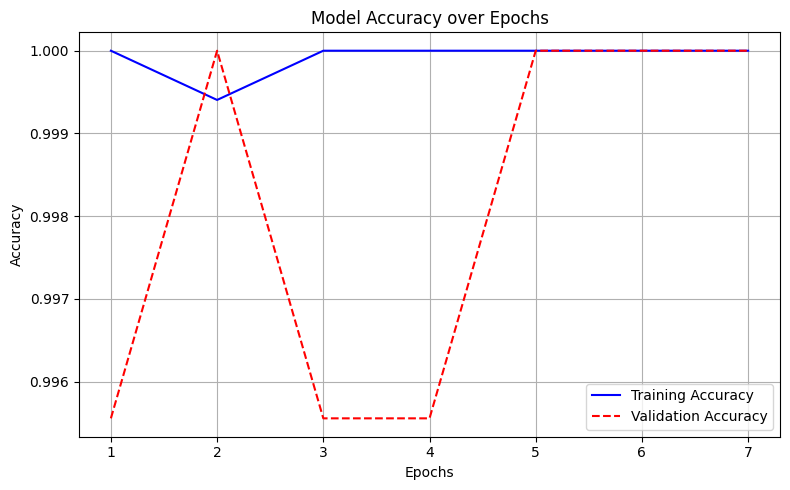

In [97]:
import matplotlib.pyplot as plt

train_acc = history.history['capsule_output_accuracy']
val_acc = history.history['val_capsule_output_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Loading best model weights from '../weights/CapsuleNet.weights.h5'...
Making predictions on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 232ms/step
Plotting confusion matrix...


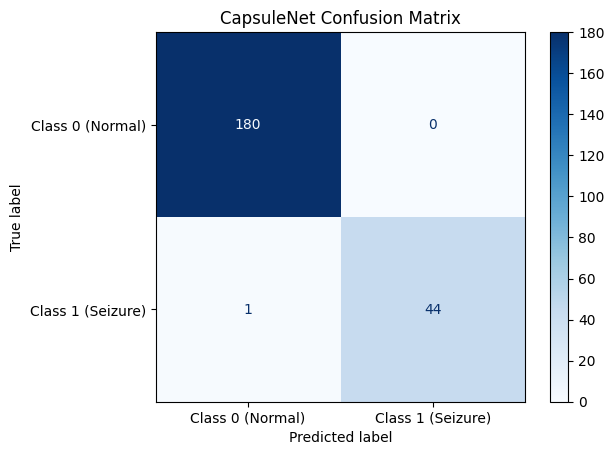


--- Classification Report ---
                   precision    recall  f1-score   support

 Class 0 (Normal)       0.99      1.00      1.00       180
Class 1 (Seizure)       1.00      0.98      0.99        45

         accuracy                           1.00       225
        macro avg       1.00      0.99      0.99       225
     weighted avg       1.00      1.00      1.00       225



In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the best weights saved during training
print("Loading best model weights from '../weights/CapsuleNet.weights.h5'...")
# We load weights into the 'model' since test_model shares its layers
model.load_weights('../weights/CapsuleNet.weights.h5')

# 2. Use the 'test_model' to make predictions on X_test
# test_model outputs a list: [capsule_lengths, decoded_images]
# We only need the first item for classification.
print("Making predictions on test set...")
y_pred_list, _ = test_model.predict(X_test)

# 3. Get the predicted class labels (0 or 1)
y_pred_classes = np.argmax(y_pred_list, axis=1)
# Get the true class labels from the one-hot encoded y_test
y_test_classes = np.argmax(y_test, axis=1)

# 4. Compute and plot confusion matrix
print("Plotting confusion matrix...")
cm = confusion_matrix(y_test_classes, y_pred_classes)

target_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

cm_display.plot(cmap=plt.cm.Blues)
plt.title('CapsuleNet Confusion Matrix')
plt.show()

# 5. Print the full classification report
print("\n--- Classification Report ---")
print(classification_report(y_test_classes, y_pred_classes, target_names=target_names))

## Without SMOTE

In [63]:
# This new cell contains all logic from Cell 4 of your SlidingWindow notebook.
# It loads CSVs, creates windowed spectrograms, splits, and normalizes.

ROOT_DATA_FOLDER = '../data/Wave Data'
NORMAL_FOLDERS = ['A', 'B', 'C', 'D']
SEIZURE_FOLDER = 'E'
FILE_EXTENSION = '*.csv'

SAMPLING_RATE_HZ = 173.33
WINDOW_DURATION_SEC = 10.0
OVERLAP_SEC = 5.0
WINDOW_SIZE = int(WINDOW_DURATION_SEC * SAMPLING_RATE_HZ)
STEP_SIZE = int(OVERLAP_SEC * SAMPLING_RATE_HZ)        

NPERSEG = 128
NOVERLAP = NPERSEG // 2  

VAL_SIZE = 0.15
TEST_SIZE = 0.15
# ----------------------------

def process_files_to_windowed_spectrograms(root_folder, normal_folders, seizure_folder, file_ext, window_size, step_size, fs, nperseg, noverlap):
    all_spectrograms = []
    all_labels = []
    all_folders = [] 
    output_shape = None 
    # Normal Folder Preprocessing
    for folder_name in normal_folders:
        folder_path = os.path.join(root_folder, folder_name)
        if not os.path.isdir(folder_path):
            print(f"Warning: Folder not found, skipping: {folder_path}")
            continue
            
        file_paths = glob.glob(os.path.join(folder_path, file_ext))
        print(f"Processing {len(file_paths)} files from {folder_path} (Label 0)...")
        
        if not file_paths:
            print(f"Warning: No files found at {folder_path} with extension {file_ext}")
            
        for file_path in file_paths:
            try:
                signal = pd.read_csv(file_path, header=None, usecols=[1]).values.flatten()
                
                num_windows = (len(signal) - window_size) // step_size + 1
                
                for i in range(num_windows):
                    start = i * step_size
                    end = start + window_size
                    
                    window_signal = signal[start:end]
                    
                    f, t, Sxx = spectrogram(window_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
                    
                    Sxx_log = np.log1p(Sxx + 1e-6)
                    
                    Sxx_log_reshaped = Sxx_log.reshape(Sxx_log.shape[0], Sxx_log.shape[1], 1)
                    
                    if output_shape is None:
                        output_shape = Sxx_log_reshaped.shape
                        print(f"Detected spectrogram shape (freq, time, channel): {output_shape}")
                    
                    all_spectrograms.append(Sxx_log_reshaped)
                    all_labels.append(0)
                    all_folders.append(folder_name)
                        
            except Exception as e:
                print(f"Warning: Could not process {file_path}. Error: {e}")
                continue
                
    # Seizure Folde Processing
    folder_path = os.path.join(root_folder, seizure_folder)
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"Error: Seizure folder not found: {folder_path}")
        
    file_paths = glob.glob(os.path.join(folder_path, file_ext))
    print(f"Processing {len(file_paths)} files from {folder_path} (Label 1)...")
    
    if not file_paths:
        print(f"Warning: No files found at {folder_path} with extension {file_ext}")
        
    for file_path in file_paths:
        try:
            signal = pd.read_csv(file_path, header=None, usecols=[1]).values.flatten()

            num_windows = (len(signal) - window_size) // step_size + 1
            
            for i in range(num_windows):
                start = i * step_size
                end = start + window_size
                window_signal = signal[start:end]
                
                f, t, Sxx = spectrogram(window_signal, fs=fs, nperseg=nperseg, noverlap=noverlap)
                Sxx_log = np.log1p(Sxx + 1e-6)
                Sxx_log_reshaped = Sxx_log.reshape(Sxx_log.shape[0], Sxx_log.shape[1], 1)
                
                all_spectrograms.append(Sxx_log_reshaped)
                all_labels.append(1) # Label 1
                all_folders.append(seizure_folder)
                
        except Exception as e:
            print(f"Warning: Could not process {file_path}. Error: {e}")
            continue
            
    if not all_spectrograms:
        raise ValueError("Error: No data was loaded.")
        
    X = np.array(all_spectrograms)
    y = np.array(all_labels)
    folders = np.array(all_folders)
    
    return X, y, folders, output_shape

def normalize_spectrograms(X_train, X_val, X_test):
    scaler = StandardScaler()
    
    num_samples_train = X_train.shape[0]
    shape_train = X_train.shape[1:]
    X_train_2d = X_train.reshape(num_samples_train, -1)

    num_samples_val = X_val.shape[0]
    shape_val = X_val.shape[1:]
    X_val_2d = X_val.reshape(num_samples_val, -1)

    num_samples_test = X_test.shape[0]
    shape_test = X_test.shape[1:]
    X_test_2d = X_test.reshape(num_samples_test, -1)
    
    scaler.fit(X_train_2d)
    
    X_train_scaled_2d = scaler.transform(X_train_2d)
    X_val_scaled_2d = scaler.transform(X_val_2d)
    X_test_scaled_2d = scaler.transform(X_test_2d)
    
    X_train_scaled = X_train_scaled_2d.reshape(num_samples_train, *shape_train)
    X_val_scaled = X_val_scaled_2d.reshape(num_samples_val, *shape_val)
    X_test_scaled = X_test_scaled_2d.reshape(num_samples_test, *shape_test)

    print("Applied Z-score normalization (fit on train data only).")
    return X_train_scaled, X_val_scaled, X_test_scaled

X, y, folders, spectro_shape = process_files_to_windowed_spectrograms(ROOT_DATA_FOLDER,NORMAL_FOLDERS,SEIZURE_FOLDER,FILE_EXTENSION,WINDOW_SIZE,STEP_SIZE,
    SAMPLING_RATE_HZ,NPERSEG,NOVERLAP)
class_counts = pd.Series(y).value_counts(normalize=True)
    
print(f"Loaded and processed {X.shape[0]} windowed spectrograms.")
print(f"Class balance:\n{class_counts * 100}")

X_train, X_temp, y_train, y_temp, folders_train, folders_temp = train_test_split(
    X, y, folders, test_size=(VAL_SIZE + TEST_SIZE), stratify=y, random_state=42
)
X_val, X_test, y_val, y_test, folders_val, folders_test = train_test_split(
    X_temp, y_temp, folders_temp,
    test_size=(TEST_SIZE / (VAL_SIZE + TEST_SIZE)), stratify=y_temp, random_state=42
)

print(f"Segregated data into 70/15/15 split:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")

X_train, X_val, X_test = normalize_spectrograms(X_train, X_val, X_test)
    
print("\nPreprocessing complete.")
print("Variables X_train, y_train, X_val, y_val, X_test, y_test are ready.")
print(f"IMPORTANT: Your model input shape is: {spectro_shape}")

Processing 100 files from ../data/Wave Data/A (Label 0)...
Detected spectrogram shape (freq, time, channel): (65, 26, 1)
Processing 100 files from ../data/Wave Data/B (Label 0)...
Processing 100 files from ../data/Wave Data/C (Label 0)...
Processing 100 files from ../data/Wave Data/D (Label 0)...
Processing 100 files from ../data/Wave Data/E (Label 1)...
Loaded and processed 1500 windowed spectrograms.
Class balance:
0    80.0
1    20.0
Name: proportion, dtype: float64
Segregated data into 70/15/15 split:
  X_train: (1050, 65, 26, 1), y_train: (1050,)
  X_val:   (225, 65, 26, 1), y_val:   (225,)
  X_test:  (225, 65, 26, 1), y_test:  (225,)
Applied Z-score normalization (fit on train data only).

Preprocessing complete.
Variables X_train, y_train, X_val, y_val, X_test, y_test are ready.
IMPORTANT: Your model input shape is: (65, 26, 1)


In [64]:
# This replaces the logic from cell 94.
# We one-hot encode the *original* y_train, not y_train_resampled.
y_val = np.eye(2)[y_val]
y_test = np.eye(2)[y_test]
y_train = np.eye(2)[y_train] # <-- The only change is here

print("--- Data shapes for training (no SMOTE) ---")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"y_val shape:   {y_val.shape}")

--- Data shapes for training (no SMOTE) ---
X_train shape: (1050, 65, 26, 1)
y_train shape: (1050, 2)
X_val shape:   (225, 65, 26, 1)
y_val shape:   (225, 2)


In [69]:
# Re-creating and re-compiling the model (from cell 138)
input_tensor = Input(shape=(65, 26, 1))

conv1_filters = max(1, optimized_values['conv1s'])
conv1_kernel = max(1, optimized_values['conv1k'])
conv2_filters = max(1, optimized_values['conv2s'])
conv2_kernel = max(1, optimized_values['conv2k'])
conv2_stride = max(1, optimized_values['conv2str'])
convrs_filters = max(1, optimized_values['convrs'])
convrk_kernel = max(1, optimized_values['convrk'])
dense1_units = max(1, optimized_values['dense1'])
dense2_units = max(1, optimized_values['dense2'])

conv1 = Conv2D(conv1_filters, (conv1_kernel, conv1_kernel), activation='relu', padding='same')(input_tensor)
conv2 = Conv2D(conv2_filters, (conv2_kernel, conv2_kernel), strides=conv2_stride, activation='relu', padding='same')(conv1)
conv2_reshaped = Conv2D(convrs_filters, (convrk_kernel, convrk_kernel), strides=2, activation='relu', padding='same')(conv2)
conv2_reshaped = MaxPooling2D(pool_size=(2, 2))(conv2_reshaped)

conv_flatten = Flatten()(conv2_reshaped)

primary_capsules_dim = max(1, optimized_values['capsuel_dim'])
h, w, c = int(conv2_reshaped.shape[1]), int(conv2_reshaped.shape[2]), int(conv2_reshaped.shape[3])
num_primary_capsules = (h * w * c) // primary_capsules_dim

primary_caps = PrimaryCapsuleLayer(num_capsules=num_primary_capsules, capsule_dim=primary_capsules_dim)(conv_flatten)
digit_caps = DigitCapsuleLayer(num_classes=2, capsule_dim=optimized_values['dig_caps'], routings=3)(primary_caps)
outputs = Lambda(output_layer, name='capsule_output')(digit_caps)

inputs_label = Input(shape=(2,))
masked = Lambda(mask)([digit_caps, inputs_label])
masked_for_test = Lambda(mask)(digit_caps)

decoded_inputs = Input(shape=(2 * optimized_values['dig_caps'],))
dense1 = Dense(dense1_units, activation='relu')(decoded_inputs)
dense2 = Dense(dense2_units, activation='relu')(dense1)

decoded_outputs = Dense(65 * 26 * 1, activation='sigmoid')(dense2) 
decoded_outputs = Reshape((65, 26, 1))(decoded_outputs)

decoder = Model(decoded_inputs, decoded_outputs)

model = Model([input_tensor, inputs_label], [outputs, decoder(masked)])
test_model = Model(input_tensor, [outputs, decoder(masked_for_test)])

model.compile(
    optimizer=Adam(learning_rate=optimized_values['lr']),
    loss=[loss_fn, 'mse'],
    loss_weights=[1., 0.0005],
    metrics=['accuracy', 'mse']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# We'll define a new checkpoint file to avoid overwriting the original one
checkpoint_no_smote = ModelCheckpoint(
    '../weights/CapsuleNet_no_SMOTE.weights.h5', # <-- New file name
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True
)

print("Model re-compiled successfully.")

Model re-compiled successfully.


In [103]:
import tensorflow as tf

# Training on the imbalanced data
history_no_smote = model.fit(
  [X_train, y_train],
  [y_train, X_train],  
  validation_data=([X_val, y_val], [y_val, X_val]), 
  epochs=30,
  batch_size=8,
  callbacks=[early_stopping, checkpoint_no_smote], # <-- Use the new checkpoint
  verbose=1
)

print("\nTraining without SMOTE complete.")

Epoch 1/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 38s 282ms/step - capsule_output_accuracy: 0.5370 - capsule_output_loss: 0.3845 - functional_6_loss: 1.2544 - functional_6_mse: 1.2545 - loss: 0.3851 - val_capsule_output_accuracy: 0.9778 - val_capsule_output_loss: 0.0175 - val_functional_6_loss: 1.0908 - val_functional_6_mse: 1.0869 - val_loss: 0.0186
Epoch 2/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 34s 256ms/step - capsule_output_accuracy: 0.9865 - capsule_output_loss: 0.0163 - functional_6_loss: 1.2350 - functional_6_mse: 1.2350 - loss: 0.0169 - val_capsule_output_accuracy: 0.9689 - val_capsule_output_loss: 0.0299 - val_functional_6_loss: 1.0893 - val_functional_6_mse: 1.0855 - val_loss: 0.0314
Epoch 3/30
132/132 ━━━━━━━━━━━━━━━━━━━━ 32s 239ms/step - capsule_output_accuracy: 0.9839 - capsule_output_loss: 0.0108 - functional_6_loss: 1.2080 - functional_6_mse: 1.2080 - loss: 0.0114 - val_capsule_output_accuracy: 0.9822 - val_capsule_output_loss: 0.0132 - val_functional_6_loss: 1.0874 - val_functional_6_ms

In [81]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

# Load weights into model (test_model shares the same weights)
model.load_weights('../weights/CapsuleNet_no_SMOTE.weights.h5')

# Get predictions — test_model returns [capsule_lengths, decoded_image]
y_pred_lengths, _ = test_model.predict(X_test)

# Convert to class indices
y_pred_classes = np.argmax(y_pred_lengths, axis=1)  # predicted
y_true_classes = np.argmax(y_test, axis=1)           # true

# Accuracy
accuracy = accuracy_score(y_true_classes, y_pred_classes)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Detailed breakdown
print(classification_report(y_true_classes, y_pred_classes, 
                             target_names=['Normal', 'Seizure']))

1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

/home/ricky/miniconda3/envs/CUDA/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 28 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Test Accuracy: 100.00%
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       180
     Seizure       1.00      1.00      1.00        45

    accuracy                           1.00       225
   macro avg       1.00      1.00      1.00       225
weighted avg       1.00      1.00      1.00       225



In [82]:
import matplotlib.pyplot as plt

train_acc = history_no_smote.history['capsule_output_accuracy']
val_acc = history_no_smote.history['val_capsule_output_accuracy']
epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy (No SMOTE)')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy (No SMOTE)')
plt.title('Model Accuracy (No SMOTE)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("accuracy_no_smote.png")
print("Saved no-SMOTE accuracy plot to accuracy_no_smote.png")

NameError: name 'history_no_smote' is not defined

Loading best model weights from '../weights/CapsuleNet_no_SMOTE.weights.h5'...
Making predictions on test set...
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step
Plotting confusion matrix (No SMOTE)...
Saved no-SMOTE confusion matrix to confusion_matrix_no_smote.png

--- Classification Report (No SMOTE) ---
                   precision    recall  f1-score   support

 Class 0 (Normal)       0.99      1.00      1.00       180
Class 1 (Seizure)       1.00      0.98      0.99        45

         accuracy                           1.00       225
        macro avg       1.00      0.99      0.99       225
     weighted avg       1.00      1.00      1.00       225



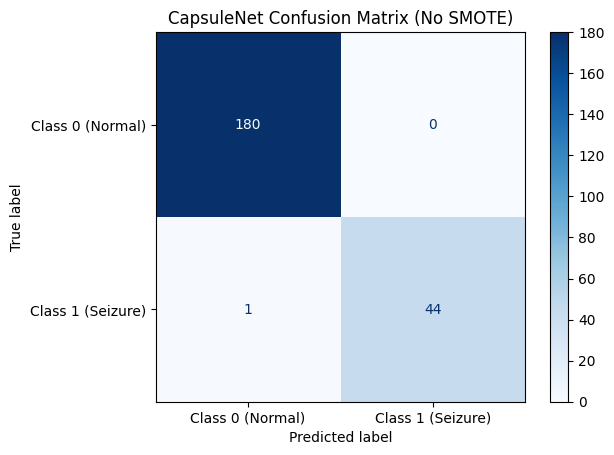

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the best weights saved during this new training
print("Loading best model weights from '../weights/CapsuleNet_no_SMOTE.weights.h5'...")
model.load_weights('../weights/CapsuleNet_no_SMOTE.weights.h5') # <-- Load new weights

# 2. Use the 'test_model' to make predictions on X_test
print("Making predictions on test set...")
y_pred_list, _ = test_model.predict(X_test)

# 3. Get the predicted class labels (0 or 1)
y_pred_classes = np.argmax(y_pred_list, axis=1)
# Get the true class labels from the one-hot encoded y_test
y_test_classes = np.argmax(y_test, axis=1)

# 4. Compute and plot confusion matrix
print("Plotting confusion matrix (No SMOTE)...")
cm = confusion_matrix(y_test_classes, y_pred_classes)

target_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

cm_display.plot(cmap=plt.cm.Blues)
plt.title('CapsuleNet Confusion Matrix (No SMOTE)')
plt.savefig("confusion_matrix_no_smote.png")
print("Saved no-SMOTE confusion matrix to confusion_matrix_no_smote.png")

# 5. Print the full classification report
print("\n--- Classification Report (No SMOTE) ---")
print(classification_report(y_test_classes, y_pred_classes, target_names=target_names))

In [106]:
import numpy as np

# --- You can change this index to test different samples ---
sample_index = 0
# ------------------------------------------------------------

# Get a single sample from the test set.
# We need to add an extra dimension [0] so it has the shape (1, 65, 26, 1)
sample = X_test[np.newaxis, sample_index]

# Get the corresponding true label
true_label_one_hot = y_test[sample_index]
true_label_index = np.argmax(true_label_one_hot)

# Use the 'test_model' to predict. It returns [predictions, decoded_image]
prediction_list, _ = test_model.predict(sample)

# Get the predicted class index
predicted_label_index = np.argmax(prediction_list[0])

# Define the class names
class_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']

# Print the results
print(f"--- Testing Sample #{sample_index} ---")
print(f"Model Prediction: {class_names[predicted_label_index]}")
print(f"Actual Label:     {class_names[true_label_index]}")

if predicted_label_index == true_label_index:
    print("\nResult: Correctly Identified!")
else:
    print("\nResult: Incorrectly Identified.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
--- Testing Sample #0 ---
Model Prediction: Class 1 (Seizure)
Actual Label:     Class 1 (Seizure)

Result: Correctly Identified!


In [123]:
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import TensorFlowV2Classifier
import numpy as np

/opt/anaconda3/envs/medres/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [125]:
# Create a new model that just has the classification output
# 'input_tensor' and 'outputs' are the tensors already defined and trained in Cell 69
attack_model = Model(input_tensor, outputs)

# ART needs to know the min/max values of your data for clipping
# We'll get this from your normalized X_test (from Cell 23)
clip_min = X_test.min()
clip_max = X_test.max()

# Wrap the model for ART. We pass it the 'loss_fn' (margin_loss) from Cell 67
art_classifier = TensorFlowV2Classifier(
    model=attack_model,
    nb_classes=2,
    input_shape=(65, 26, 1),
    loss_object=loss_fn,  # Using the margin_loss from your notebook
    clip_values=(clip_min, clip_max)
)

In [127]:
# Create the FGM attack
# eps=0.1 is a good starting point for normalized data.
# Higher values = stronger (but more obvious) attack.
attack_fgm = FastGradientMethod(estimator=art_classifier, eps=0.1)

print("Generating adversarial examples...")
# Create the new adversarial test set from your original X_test
X_test_adv = attack_fgm.generate(x=X_test)

print("Generation complete.")

Generating adversarial examples...
Generation complete.


In [129]:
# 1. Get predictions on the CLEAN data
preds_clean = attack_model.predict(X_test)
preds_clean_classes = np.argmax(preds_clean, axis=1)
y_test_classes = np.argmax(y_test, axis=1) # Convert one-hot y_test to labels

acc_clean = np.sum(preds_clean_classes == y_test_classes) / len(y_test_classes)
print(f"Accuracy on CLEAN data (Baseline):   {acc_clean * 100:.2f}%")

# 2. Get predictions on the ADVERSARIAL data
preds_adv = attack_model.predict(X_test_adv)
preds_adv_classes = np.argmax(preds_adv, axis=1)

acc_adv = np.sum(preds_adv_classes == y_test_classes) / len(y_test_classes)
print(f"Accuracy on ADVERSARIAL data (FGM):  {acc_adv * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step
Accuracy on CLEAN data (Baseline):   99.56%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step
Accuracy on ADVERSARIAL data (FGM):  100.00%



--- ADVERSARIAL Classification Report ---
                   precision    recall  f1-score   support

 Class 0 (Normal)       1.00      1.00      1.00       180
Class 1 (Seizure)       1.00      1.00      1.00        45

         accuracy                           1.00       225
        macro avg       1.00      1.00      1.00       225
     weighted avg       1.00      1.00      1.00       225


--- ADVERSARIAL Confusion Matrix ---


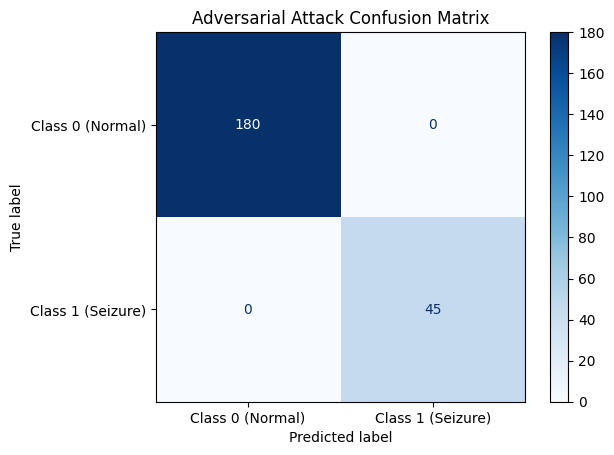

In [131]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("\n--- ADVERSARIAL Classification Report ---")
target_names = ['Class 0 (Normal)', 'Class 1 (Seizure)']
print(classification_report(y_test_classes, preds_adv_classes, target_names=target_names))

# Compute and display the confusion matrix for the adversarial attack
print("\n--- ADVERSARIAL Confusion Matrix ---")
cm_adv = confusion_matrix(y_test_classes, preds_adv_classes)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm_adv, display_labels=target_names)

cm_display.plot(cmap=plt.cm.Blues)
plt.title("Adversarial Attack Confusion Matrix")
plt.show()

=== Adversarial Difference Summary ===
Any difference (tol=1e-06): True
All equal: False
Mean abs diff (global): 2.000001e-02
Median abs diff (global): 1.134026e-08
Max abs diff: 1.000002e-01
Std abs diff: 3.999999e-02
Samples changed: 45 / 225 (20.00%)
Mean L2 perturbation (per-sample): 8.221928e-01
Max  L2 perturbation (per-sample): 4.110961e+00


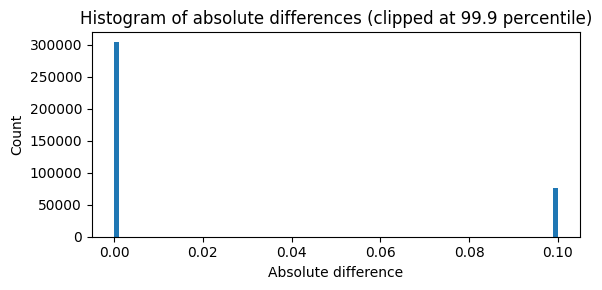

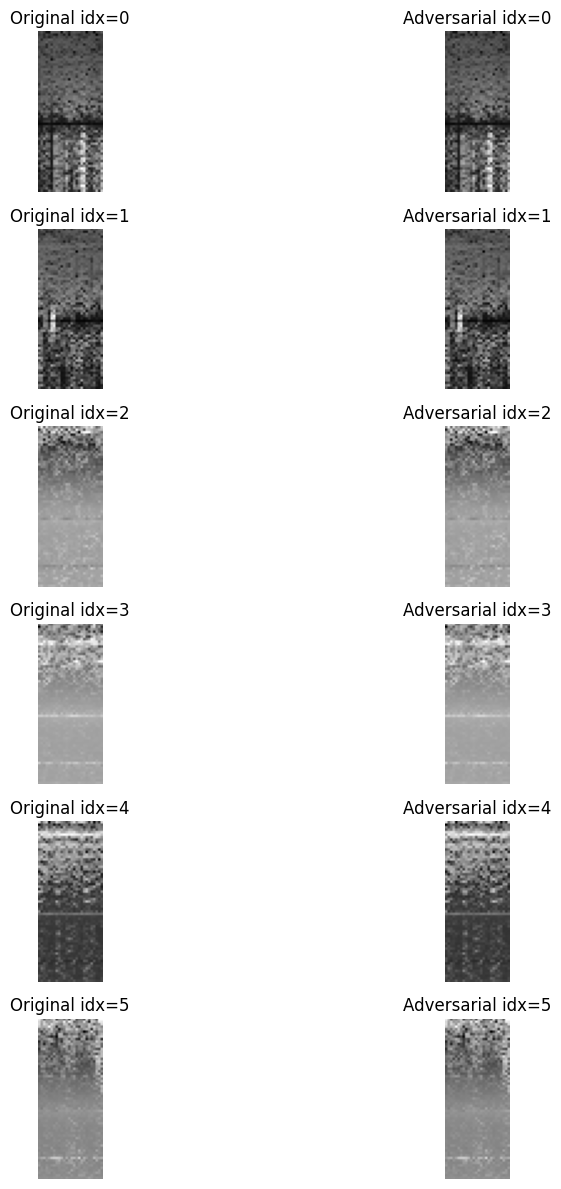


Sanity checks:
Mean absolute difference (fast): 0.020000009611626044
Number of exactly equal elements: 0
Percent exactly equal elements: 0.0


In [133]:
# Paste and run this in the same notebook where you have X_test and X_test_adv defined.
import numpy as np
import matplotlib.pyplot as plt

def summarize_adv(X_clean, X_adv, tol=1e-6, show_hist=True):
    """
    Summarize differences between X_clean and X_adv.
    - tol: tolerance for comparing floats (treat differences <= tol as no change).
    Returns a dict of stats.
    """
    assert X_clean.shape == X_adv.shape, "X_clean and X_adv must have same shape"
    diff = X_adv - X_clean
    abs_diff = np.abs(diff).astype(np.float64)

    stats = {}
    stats['mean_abs_diff'] = float(np.mean(abs_diff))
    stats['median_abs_diff'] = float(np.median(abs_diff))
    stats['max_abs_diff'] = float(np.max(abs_diff))
    stats['std_abs_diff'] = float(np.std(abs_diff))

    # per-sample (useful to see how many examples changed)
    sample_abs = abs_diff.reshape((abs_diff.shape[0], -1)).mean(axis=1)
    stats['mean_abs_diff_per_sample_mean'] = float(sample_abs.mean())
    stats['mean_abs_diff_per_sample_median'] = float(np.median(sample_abs))
    stats['num_samples_changed'] = int(np.sum(sample_abs > tol))
    stats['pct_samples_changed'] = float(100.0 * stats['num_samples_changed'] / X_clean.shape[0])

    # L2 norms of perturbations
    l2_per_sample = np.linalg.norm(abs_diff.reshape(abs_diff.shape[0], -1), axis=1)
    stats['mean_l2'] = float(np.mean(l2_per_sample))
    stats['max_l2'] = float(np.max(l2_per_sample))

    # quick boolean checks
    stats['any_diff'] = bool(np.any(abs_diff > tol))
    stats['all_equal'] = not stats['any_diff']

    # print summary
    print("=== Adversarial Difference Summary ===")
    print(f"Any difference (tol={tol}): {stats['any_diff']}")
    print(f"All equal: {stats['all_equal']}")
    print(f"Mean abs diff (global): {stats['mean_abs_diff']:.6e}")
    print(f"Median abs diff (global): {stats['median_abs_diff']:.6e}")
    print(f"Max abs diff: {stats['max_abs_diff']:.6e}")
    print(f"Std abs diff: {stats['std_abs_diff']:.6e}")
    print(f"Samples changed: {stats['num_samples_changed']} / {X_clean.shape[0]} ({stats['pct_samples_changed']:.2f}%)")
    print(f"Mean L2 perturbation (per-sample): {stats['mean_l2']:.6e}")
    print(f"Max  L2 perturbation (per-sample): {stats['max_l2']:.6e}")

    if show_hist:
        flat = abs_diff.ravel()
        plt.figure(figsize=(6,3))
        plt.hist(flat, bins=100, range=(np.min(flat), np.percentile(flat, 99.9)))
        plt.title("Histogram of absolute differences (clipped at 99.9 percentile)")
        plt.xlabel("Absolute difference")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

    return stats

def visualize_examples(X_clean, X_adv, y=None, idxs=None, n=6, figsize=(12,6), cmap=None):
    """
    Visualize original vs adv for a set of indices.
    Detects image-like (>=2D per sample) or 1D signals and uses appropriate plotting.
    - idxs: list of indices to plot. if None, choose first n.
    - y: optional labels to show in titles.
    """
    if idxs is None:
        idxs = list(range(min(n, X_clean.shape[0])))
    else:
        idxs = list(idxs)

    n = len(idxs)
    # determine sample shape type
    sample_shape = X_clean.shape[1:]
    is_image = (X_clean.ndim == 4) or (X_clean.ndim == 3 and (len(sample_shape) == 2))
    # if 1D signal: shape (n, T)
    is_1d = (X_clean.ndim == 2)

    cols = 2
    rows = n
    plt.figure(figsize=figsize)
    for i, idx in enumerate(idxs):
        x = X_clean[idx]
        xa = X_adv[idx]
        title_suffix = f" idx={idx}" + (f" label={y[idx]}" if y is not None else "")

        plt.subplot(rows, cols, 2*i+1)
        if is_image:
            # For images: if channels last and >1, show as is; if single channel, squeeze
            if x.ndim == 3 and x.shape[-1] == 1:
                plt.imshow(x.squeeze(), cmap=cmap)
            elif x.ndim == 3:
                plt.imshow(x)
            else:
                plt.imshow(x, cmap=cmap)
            plt.title("Original" + title_suffix)
            plt.axis('off')
        elif is_1d:
            plt.plot(x)
            plt.title("Original" + title_suffix)
            plt.grid(True)

        plt.subplot(rows, cols, 2*i+2)
        if is_image:
            if xa.ndim == 3 and xa.shape[-1] == 1:
                plt.imshow(xa.squeeze(), cmap=cmap)
            elif xa.ndim == 3:
                plt.imshow(xa)
            else:
                plt.imshow(xa, cmap=cmap)
            plt.title("Adversarial" + title_suffix)
            plt.axis('off')
        elif is_1d:
            plt.plot(xa)
            plt.title("Adversarial" + title_suffix)
            plt.grid(True)

    plt.tight_layout()
    plt.show()

# === USAGE ===
# Example: run the checks
# Replace/ensure X_test and X_test_adv are in scope

# Stats
stats = summarize_adv(X_test, X_test_adv, tol=1e-6, show_hist=True)

# Visualize a few examples (first 6 by default)
visualize_examples(X_test, X_test_adv, y=None, idxs=None, n=6, figsize=(12, 12), cmap='gray')

# Quick pixel difference sanity checks
print("\nSanity checks:")
print("Mean absolute difference (fast):", np.mean(np.abs(X_test_adv - X_test)))
print("Number of exactly equal elements:", int(np.sum((X_test_adv == X_test).ravel())))
print("Percent exactly equal elements:",
      100.0 * int(np.sum((X_test_adv == X_test).ravel())) / X_test.ravel().shape[0])


Evaluating model robustness across eps values...

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step
eps=0.000 → Accuracy=99.56%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step
eps=0.033 → Accuracy=99.56%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step
eps=0.067 → Accuracy=100.00%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step
eps=0.100 → Accuracy=100.00%
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 363ms/step
eps=0.133 → Accuracy=98.67%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 221ms/step
eps=0.167 → Accuracy=98.22%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 215ms/step
eps=0.200 → Accuracy=97.33%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step
eps=0.233 → Accuracy=94.67%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 214ms/step
eps=0.267 → Accuracy=92.89%
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step
eps=0.300 → Accuracy=92.00%

Baseline accuracy on CLEAN data: 99.56%


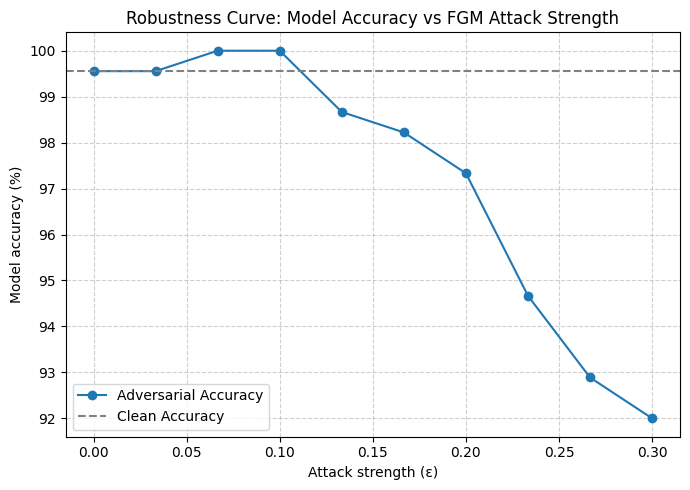

In [135]:
import numpy as np
import matplotlib.pyplot as plt
from art.attacks.evasion import FastGradientMethod

# Define a range of eps values (attack strengths)
eps_values = np.linspace(0, 0.3, 10)  # you can adjust range (0 to 0.3) or number of points (10)
acc_clean = None
accuracies = []

print("Evaluating model robustness across eps values...\n")

for eps in eps_values:
    # Create new attack for each eps
    attack_fgm = FastGradientMethod(estimator=art_classifier, eps=eps)
    
    # Generate adversarial examples
    X_test_adv = attack_fgm.generate(x=X_test)
    
    # Evaluate on adversarial data
    preds_adv = attack_model.predict(X_test_adv)
    preds_adv_classes = np.argmax(preds_adv, axis=1)
    y_test_classes = np.argmax(y_test, axis=1)
    
    acc_adv = np.mean(preds_adv_classes == y_test_classes)
    
    if acc_clean is None:
        # Compute baseline (clean accuracy) once
        preds_clean = attack_model.predict(X_test)
        preds_clean_classes = np.argmax(preds_clean, axis=1)
        acc_clean = np.mean(preds_clean_classes == y_test_classes)
    
    accuracies.append(acc_adv)
    print(f"eps={eps:.3f} → Accuracy={acc_adv*100:.2f}%")

print("\nBaseline accuracy on CLEAN data: {:.2f}%".format(acc_clean*100))

# === Plot robustness curve ===
plt.figure(figsize=(7,5))
plt.plot(eps_values, np.array(accuracies)*100, marker='o', label='Adversarial Accuracy')
plt.axhline(acc_clean*100, color='gray', linestyle='--', label='Clean Accuracy')
plt.xlabel("Attack strength (ε)")
plt.ylabel("Model accuracy (%)")
plt.title("Robustness Curve: Model Accuracy vs FGM Attack Strength")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [143]:
import numpy as np

# This cell evaluates both models on the final, unseen test set.
# We use model.evaluate() to get the compiled loss and accuracy metrics.

# The data X_test and y_test are already loaded and one-hot encoded from cell 101.
# The 'model' object is already compiled from cell 102.

print("--- Evaluating Model WITH SMOTE ---")
print("Loading weights from '../weights/CapsuleNet.weights.h5'...")

# 1. Load the weights from the model trained WITH SMOTE
model.load_weights('../weights/CapsuleNet.weights.h5')

# 2. Evaluate on the test set
# model.evaluate() returns a list of scalars:
# [total_loss, capsule_output_loss, functional_N_loss, capsule_output_accuracy, functional_N_mse]
# We will access these by their index (0, 1, 3)
# The model.metrics_names list seems to be reported incorrectly by Keras in this notebook, so we will ignore it.
metrics_with_smote = model.evaluate(
    [X_test, y_test],  
    [y_test, X_test],
    batch_size=8,
    verbose=0
)

print(f"\nTest Set Metrics (With SMOTE):")
try:
    print(f"  Total Test Loss:     {metrics_with_smote[0]:.4f}")
    print(f"  Test Loss (Capsule): {metrics_with_smote[1]:.4f}")
    print(f"  Test Accuracy:       {metrics_with_smote[3]*100:.2f}%") # Index 3 should be 'capsule_output_accuracy'
except IndexError:
    print("  Error: Could not retrieve metrics. The model.evaluate() output list had an unexpected length.")
    print(f"  Full metrics list returned: {metrics_with_smote}")
print("-" * 40)


print("\n--- Evaluating Model WITHOUT SMOTE ---")
print("Loading weights from '../weights/CapsuleNet_no_SMOTE.weights.h5'...")

# 1. Load the weights from the model trained WITHOUT SMOTE
model.load_weights('../weights/CapsuleNet_no_SMOTE.weights.h5')

# 2. Evaluate on the test set
metrics_no_smote = model.evaluate(
    [X_test, y_test],  
    [y_test, X_test],
    batch_size=8,
    verbose=0
)

# The indices will be the same
print(f"\nTest Set Metrics (Without SMOTE):")
try:
    print(f"  Total Test Loss:     {metrics_no_smote[0]:.4f}")
    print(f"  Test Loss (Capsule): {metrics_no_smote[1]:.4f}")
    print(f"  Test Accuracy:       {metrics_no_smote[3]*100:.2f}%") # Index 3 should be 'capsule_output_accuracy'
except IndexError:
    print("  Error: Could not retrieve metrics. The model.evaluate() output list had an unexpected length.")
    print(f"  Full metrics list returned: {metrics_no_smote}")

print("-" * 40)

--- Evaluating Model WITH SMOTE ---
Loading weights from '../weights/CapsuleNet.weights.h5'...

Test Set Metrics (With SMOTE):
  Total Test Loss:     0.0032
  Test Loss (Capsule): 0.0028
  Test Accuracy:       99.56%
----------------------------------------

--- Evaluating Model WITHOUT SMOTE ---
Loading weights from '../weights/CapsuleNet_no_SMOTE.weights.h5'...

Test Set Metrics (Without SMOTE):
  Total Test Loss:     0.0024
  Test Loss (Capsule): 0.0020
  Test Accuracy:       99.56%
----------------------------------------


## Aequitas

In [84]:
import pandas as pd
from aequitas.group import Group
from aequitas.bias import Bias
from aequitas.fairness import Fairness
from aequitas.plotting import Plot

# --- 1. Get predictions on test set ---
y_pred_lengths, _ = test_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_lengths, axis=1)

# Convert one-hot y_test back to integer labels
y_test_classes = np.argmax(y_test, axis=1)

# --- 2. Add a meaningful recording_condition attribute ---
patient_type_map = {
    'A': 'healthy',            
    'B': 'healthy',             
    'C': 'epileptic_nonsz',     
    'D': 'epileptic_nonsz',    
    'E': 'epileptic_sz'        
}

patient_types = np.array([patient_type_map[f] for f in folders_test])

# --- 3. Build the Aequitas-ready DataFrame ---
aequitas_df = pd.DataFrame({
    'score':        y_pred_classes.astype(int),
    'label_value':  y_test_classes.astype(int),
    'patient_type': patient_types,
    'source_folder': folders_test   # keep for finer-grained audit if needed
})

# Sanity check — confirm labels per group
print(aequitas_df.groupby(['patient_type', 'label_value']).size())

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
patient_type     label_value
epileptic_nonsz  0              99
epileptic_sz     1              45
healthy          0              81
dtype: int64


In [85]:
g = Group()
xtab, _ = g.get_crosstabs(aequitas_df, attr_cols=['patient_type'])

# For healthy and epileptic_nonsz → FPR is meaningful (all label=0)
# For epileptic_sz             → TPR / FNR is meaningful (all label=1)
print(xtab[[
    'attribute_name', 'attribute_value',
    'group_size', 'tpr', 'fpr', 'fnr', 'tnr'
]])

# ── Disparity metrics ────────────────────────────────────────────────────────
b = Bias()

# Reference = 'healthy' → compare epileptic_nonsz FPR against healthy baseline
bdf = b.get_disparity_predefined_groups(
    xtab,
    original_df=aequitas_df,
    ref_groups_dict={'patient_type': 'healthy'}
)

print(bdf[[
    'attribute_name', 'attribute_value',
    'fpr', 'fpr_disparity',   # ← most meaningful: false alarm rate per group
    'tpr', 'tpr_disparity',
    'fnr', 'fnr_disparity'
]])

# ── Fairness assessment ──────────────────────────────────────────────────────
f = Fairness()
fdf = f.get_group_value_fairness(bdf)

print("\nFairness Summary:")
print(fdf[[
    'attribute_name', 'attribute_value',
    'TPR Parity', 'FDR Parity', 'FPR Parity', 'FNR Parity'
]].to_string(index=False))

# Overall pass/fail
fair_results = f.get_overall_fairness(fdf)
print("\nOverall Fairness:", fair_results)

  attribute_name  attribute_value  group_size  tpr  fpr  fnr  tnr
0   patient_type  epileptic_nonsz          99  NaN  0.0  NaN  1.0
1   patient_type     epileptic_sz          45  1.0  NaN  0.0  NaN
2   patient_type          healthy          81  NaN  0.0  NaN  1.0
  attribute_name  attribute_value  fpr  fpr_disparity  tpr  tpr_disparity  \
0   patient_type  epileptic_nonsz  0.0            NaN  NaN            NaN   
1   patient_type     epileptic_sz  NaN            NaN  1.0            NaN   
2   patient_type          healthy  0.0            NaN  NaN            NaN   

   fnr  fnr_disparity  
0  NaN            NaN  
1  0.0            NaN  
2  NaN            NaN  

Fairness Summary:
attribute_name attribute_value  TPR Parity  FDR Parity  FPR Parity  FNR Parity
  patient_type epileptic_nonsz         NaN         NaN         NaN         NaN
  patient_type    epileptic_sz         NaN         NaN         NaN         NaN
  patient_type         healthy         NaN         NaN         NaN         

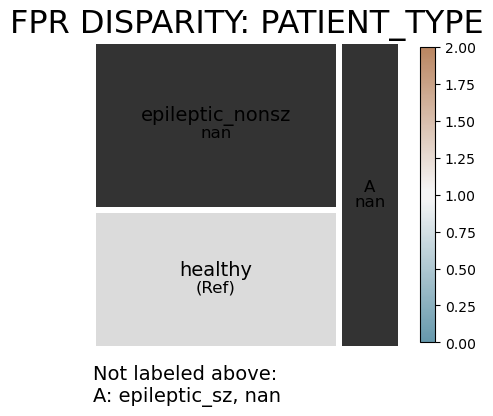

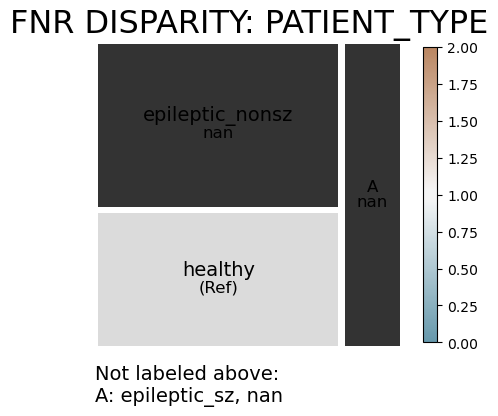

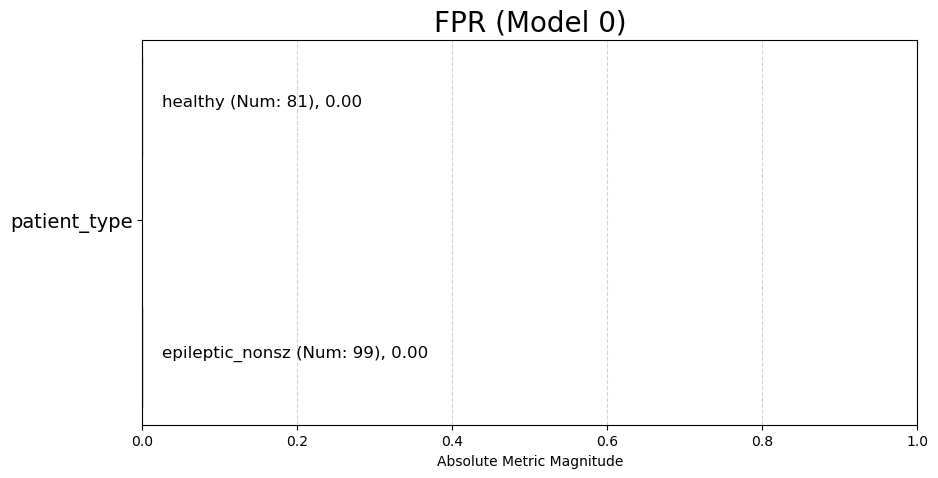

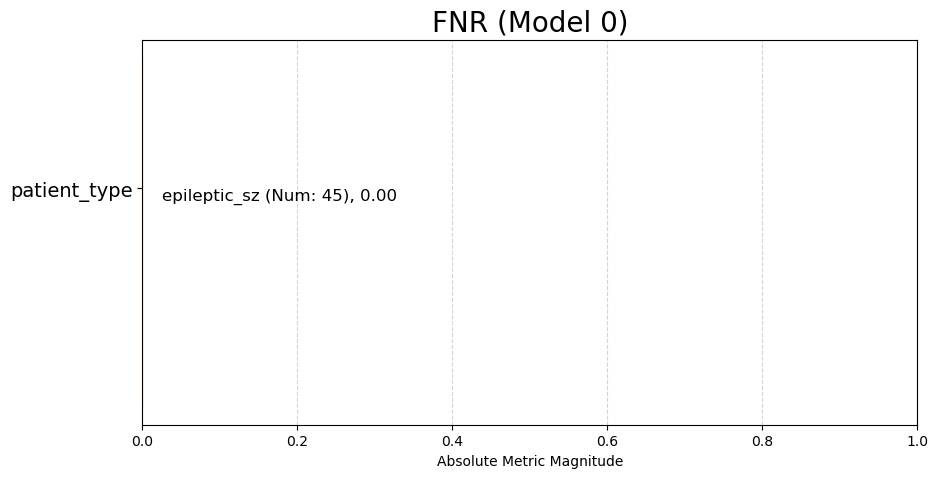

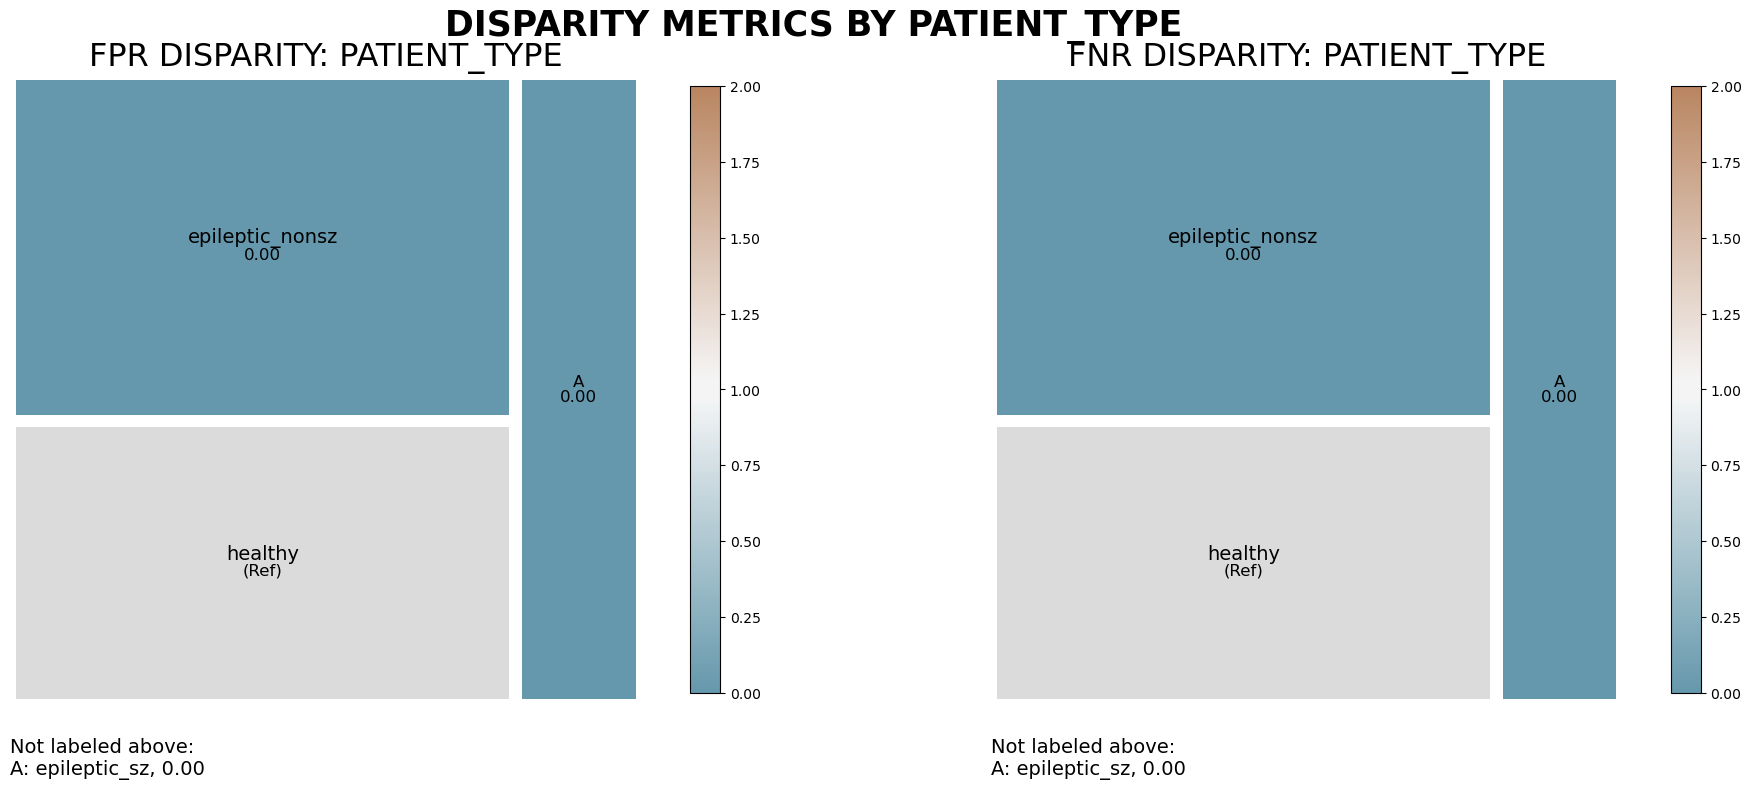

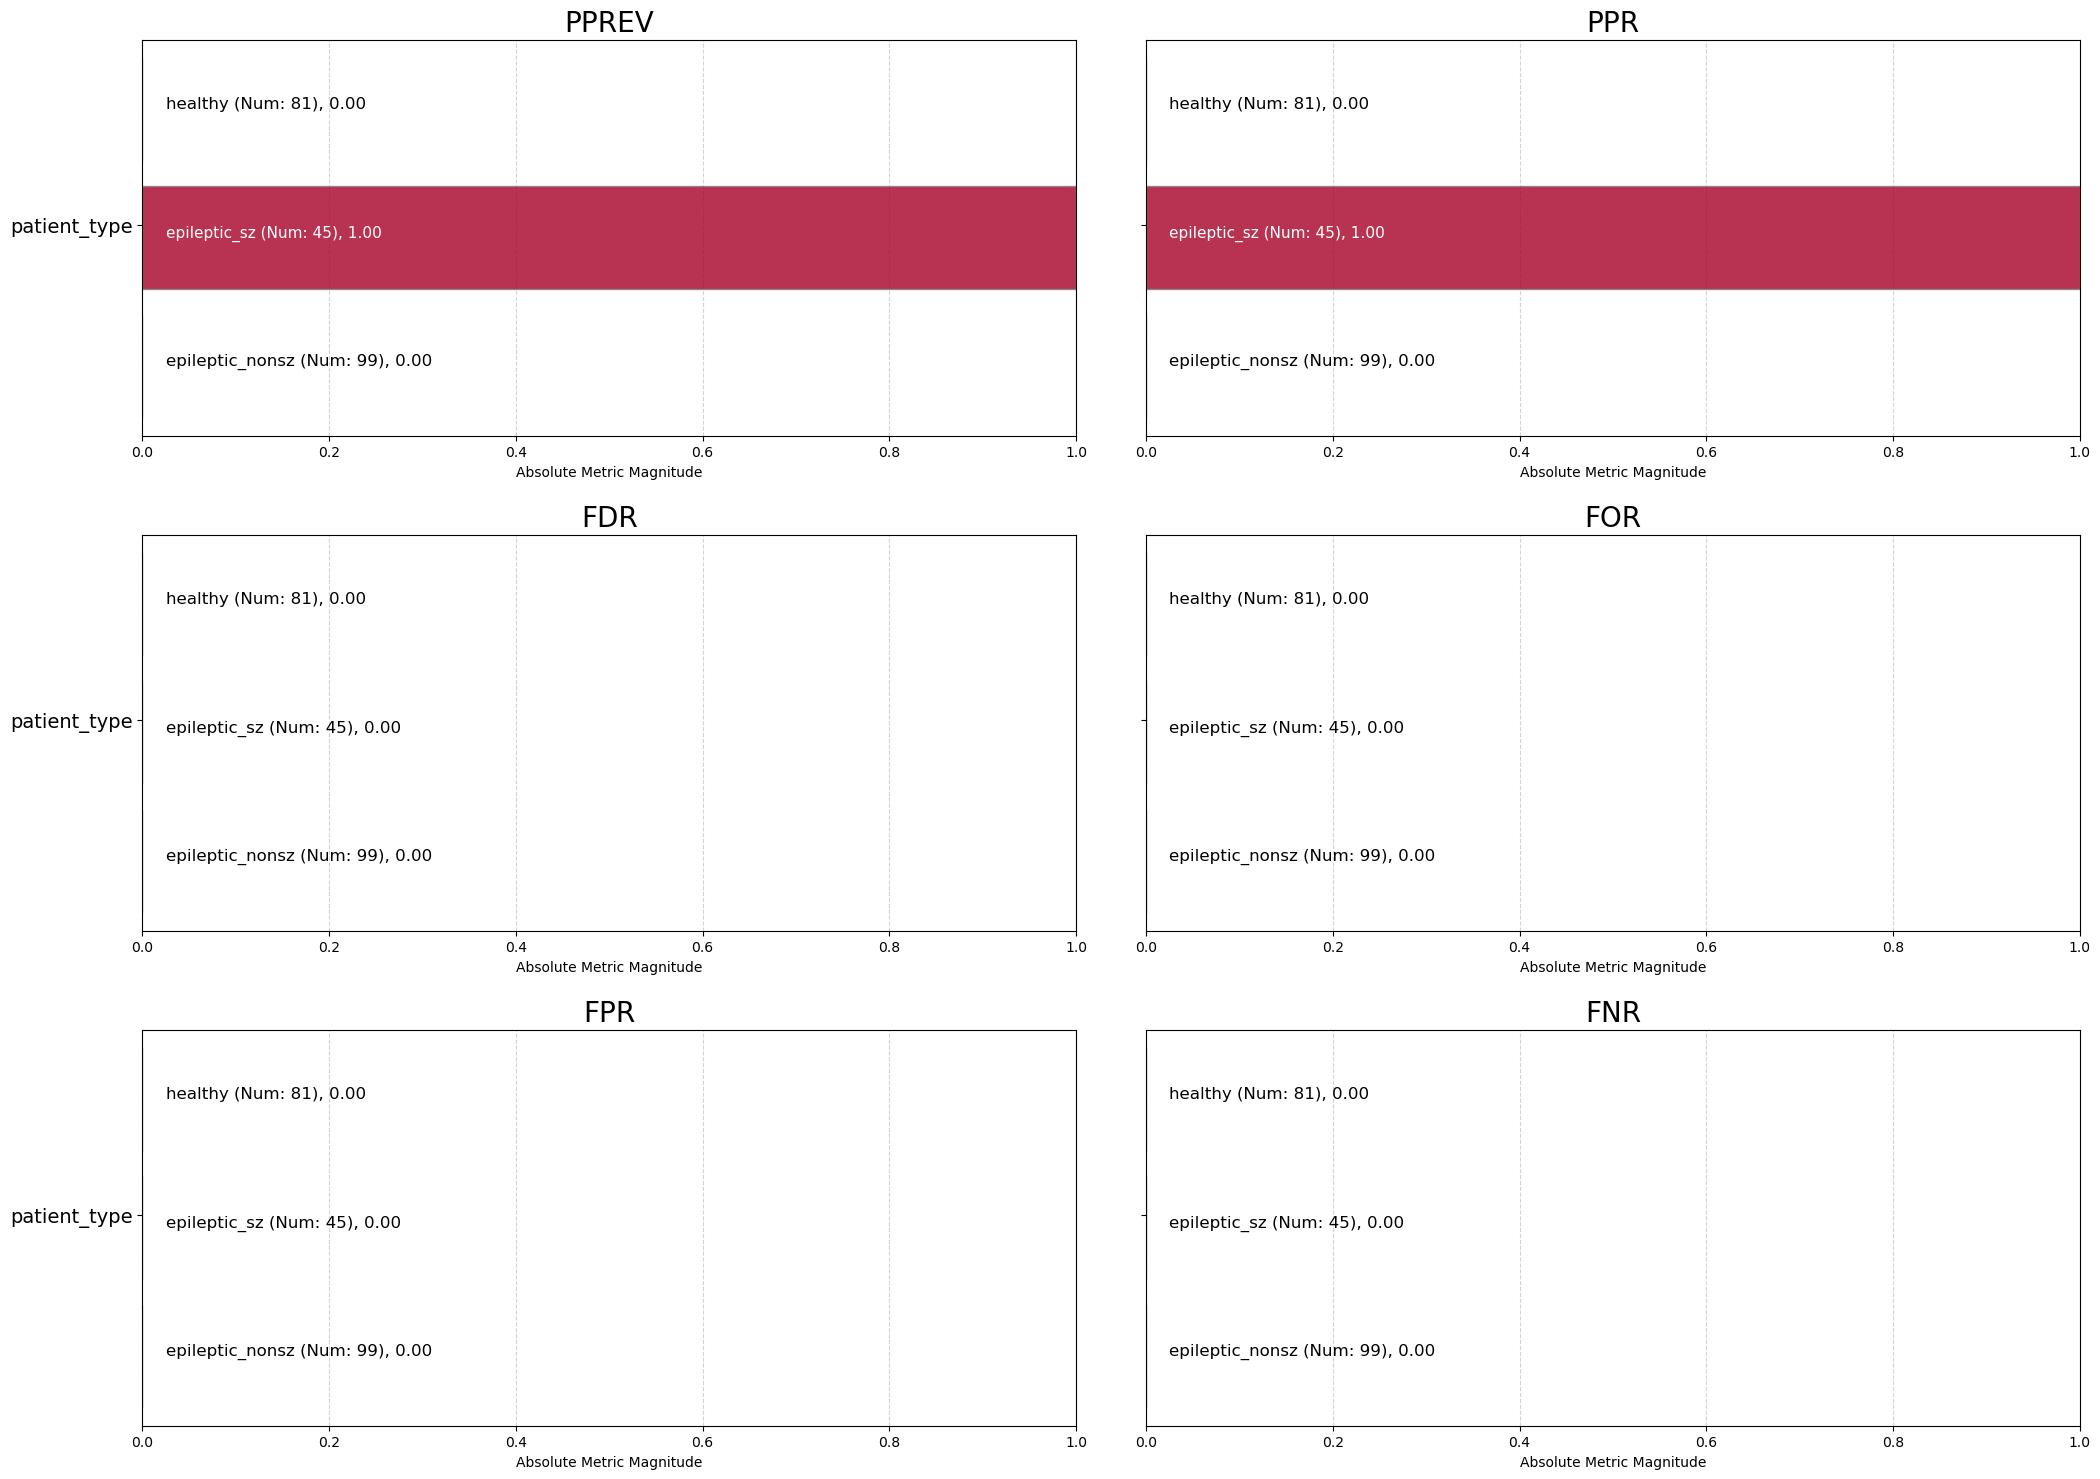

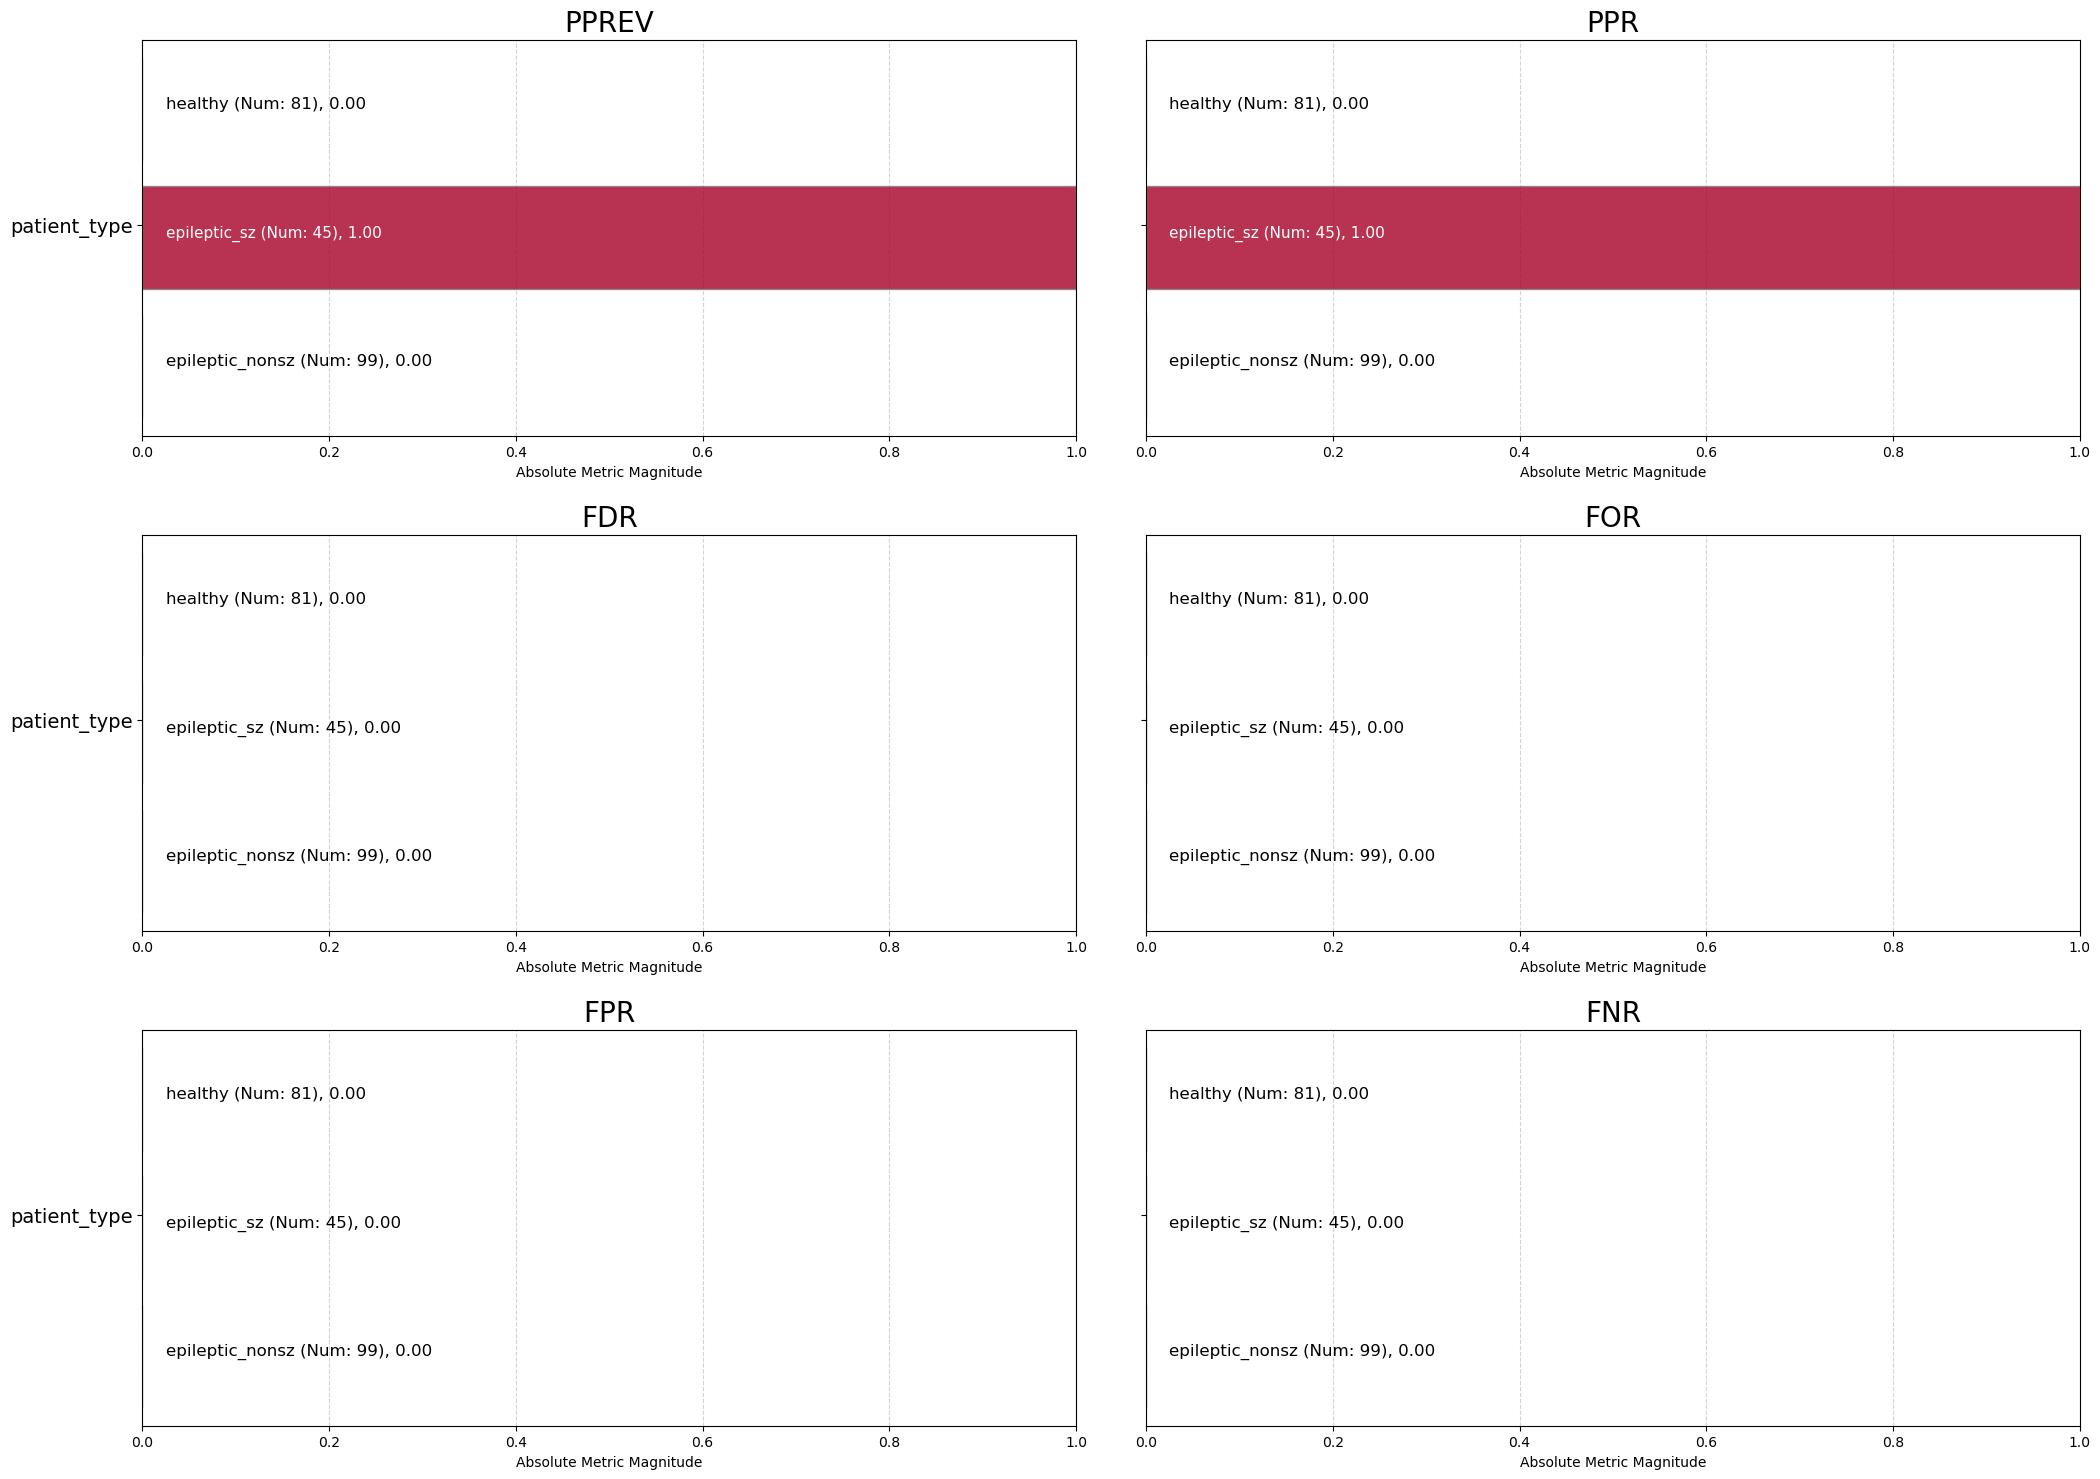

<Figure size 640x480 with 0 Axes>

In [86]:
aqp = Plot()

# Plot 1: FPR disparity across patient types (treemap) — core fairness question
aqp.plot_disparity(bdf, 'fpr_disparity', 'patient_type')

# Plot 2: FNR disparity across patient types (missed seizures)
aqp.plot_disparity(bdf, 'fnr_disparity', 'patient_type')

# Plot 3: Raw FPR per group (absolute, not relative)
aqp.plot_group_metric(xtab, 'fpr')

# Plot 4: Raw FNR per group
aqp.plot_group_metric(xtab, 'fnr')

# Plot 5: All disparity metrics at once
aqp.plot_disparity_all(bdf, attributes=['patient_type'], metrics=['fpr_disparity', 'fnr_disparity'])

# Plot 6: Full fairness overview (colored by pass/fail)
aqp.plot_fairness_group_all(fdf, ncols=2)